Classification Task and Class Label Definition




This project focuses on automatically classifying privacy policy text segments into predefined privacy practice categories using Natural Language Processing (NLP) and machine learning techniques. The task is formulated as an 8-class single-label text classification problem, where each input instance is a text span extracted from a privacy policy clause, and the objective is to predict the corresponding privacy practice category.

The dataset contains 17,343 annotated privacy policy segments collected from the OPP-115 privacy policy corpus. Each text segment is assigned one class \label representing the type of data practice described in that segment. The target variable for classification is the category column, which contains the following eight classes: First Party Collection/Use,Third Party Sharing/Collection, User Choice/Control, Data Security,User Access, Edit and Deletion,
International and Specific Audiences,Policy Change, Data Retention

Real-World Relevance of the Problem

Privacy policies are important legal documents that explain how organizations collect, use, share, and protect users’ personal information. However, these documents are often lengthy, complex, and written using legal or technical terminology, making it difficult for ordinary users to understand their privacy rights and potential risks.
With the increasing amount of personal data collected by online platforms, automatically identifying privacy practices has become an important challenge. A machine learning-based privacy policy classification system can help users, organizations, and regulatory bodies quickly analyze large volumes of privacy documents and identify important information related to data handling practices.

**3.2 Dataset Collection and Description**



The dataset used in this project is the Online Privacy Policies (OPP-115) dataset, which is a benchmark dataset developed for analyzing and understanding privacy policy documents using natural language processing techniques. The dataset contains privacy policy text collected from 115 websites belonging to different domains, including online services, commercial websites, and digital platforms.

The original privacy policies were manually annotated by privacy experts to identify specific data practices described in each text segment. Instead of classifying complete privacy policies, the dataset divides policies into smaller meaningful text spans, where each span represents a particular privacy-related statement. These annotations provide a structured representation of how organizations collect, use, share, and manage users’ personal information.

For this project, the dataset file privacy_policy_dataset.csv is used. Each record contains a privacy policy text segment along with its corresponding category label. The main objective is to train machine learning models to automatically identify the privacy practice category from unseen policy text.

Dataset Characteristics

The dataset contains 17,343 privacy policy text samples with two main components:
text and category

The input variable is unstructured textual data, which requires natural language processing techniques such as text cleaning, tokenization, vectorization, and feature extraction before applying classification algorithms.

The target variable is the privacy practice category, consisting of eight different classes:        
 First Party Collection/Use,Third Party Sharing/Collection, User Choice/Control, Data Security,User Access, Edit and Deletion,
International and Specific Audiences,Policy Change, Data Retention

Key Characteristics of the Dataset:

1)Text-based classification problem
2)Multi-class classification
3)Domain-specific vocabulary
4)Class Imbalance
5)Real-world privacy language
6)Suitable benchmark for NLP research

**3.3  Dataset Collection and Description**


In [1]:
!pip install gensim
import json
import os
import re
import string
import warnings
from collections import Counter

import numpy as np
import pandas as pd

from gensim.models import Word2Vec

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 72.9 MB/s eta 0:00:00


In [2]:
# Required NLP and deep learning dependencies

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

for resource, path in [
    ("punkt", "tokenizers/punkt"),
    ("punkt_tab", "tokenizers/punkt_tab"), # Added missing resource
    ("stopwords", "corpora/stopwords"),
    ("wordnet", "corpora/wordnet")
]:
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(resource, quiet=True)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("Required NLP and deep learning dependencies loaded successfully")

Required NLP and deep learning dependencies loaded successfully


below block is unnecessary(maybe in the last for the summary)


In [3]:
CATEGORIES = [
    "First Party Collection/Use",
    "Third Party Sharing/Collection",
    "User Choice/Control",
    "Data Security",
    "User Access, Edit and Deletion",
    "International and Specific Audiences",
    "Policy Change",
    "Data Retention",
]

print(f"Task            : single-label, {len(CATEGORIES)}-class text classification")
print(f"Input           : annotated span (`text` column)")
print(f"Context carried : full clause (`clause_text` column), not used as sole input")
print(f"Primary metric  : macro-F1\n")
print("Categories:")
for i, c in enumerate(CATEGORIES, 1):
    print(f"  {i}. {c}")

Task            : single-label, 8-class text classification
Input           : annotated span (`text` column)
Context carried : full clause (`clause_text` column), not used as sole input
Primary metric  : macro-F1

Categories:
  1. First Party Collection/Use
  2. Third Party Sharing/Collection
  3. User Choice/Control
  4. Data Security
  5. User Access, Edit and Deletion
  6. International and Specific Audiences
  7. Policy Change
  8. Data Retention


# **Dataset Loading**

In [4]:
import pandas as pd
privacy_policy_dataset = "privacy_policy_dataset.csv"

df = pd.read_csv(privacy_policy_dataset)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
print("Columns and dtypes:")
print(df.dtypes.to_string())

Shape: 17,343 rows x 17 columns

Columns and dtypes:
sample_id              object
text                   object
category               object
split                  object
source_file            object
segment_id              int64
annotation_count        int64
annotator_count         int64
annotator_ids          object
annotation_ids         object
policy_id               int64
policy_url             object
date                   object
selected_span_count     int64
word_count              int64
char_count              int64
clause_text            object


Observation Dataset's row and columns

In [5]:
print("First 20 rows, key columns only:\n")
preview = df[["sample_id", "policy_id", "segment_id", "category", "split", "text"]].head(20).copy()
preview["text"] = preview["text"].str.slice(0, 70) + "..."
print(preview.to_string(index=False))

print("\n\nOne full example row:\n")
row = df.iloc[0]
print(f"  sample_id  : {row['sample_id']}")
print(f"  policy_id  : {row['policy_id']}  (segment {row['segment_id']})")
print(f"  category   : {row['category']}")
print(f"  split      : {row['split']}")
print(f"  span       : {row['text'][:200]}")
print(f"  clause     : {str(row['clause_text'])[:200]}...")

First 20 rows, key columns only:

sample_id  policy_id  segment_id                             category split                                                                      text
  PP00001       1017           0                        Policy Change train                    Please note that these terms are subject to change,...
  PP00002       1017           1           First Party Collection/Use train    other purposes, for example when you report a problem with our site...
  PP00003       1017           1           First Party Collection/Use train    other purposes, for example when you report a problem with our site...
  PP00004       1017           1           First Party Collection/Use train names, e-mail and website addresses; we may also ask you for informati...
  PP00005       1017           1           First Party Collection/Use train                       that you provide by filling in forms on our site...
  PP00006       1017           1           First Party Collection/

# EDA: EXPLORATORY DATA ANALYSIS

In [6]:
n_rows = len(df)
n_policies = df["policy_id"].nunique()
n_clauses = df["clause_text"].nunique()
n_spans = df["text"].nunique()
n_categories = df["category"].nunique()

print(f"Rows (annotation-derived instances) : {n_rows:,}")
print(f"Distinct policies                   : {n_policies:,}")
print(f"Distinct underlying clauses         : {n_clauses:,}")
print(f"Distinct spans                      : {n_spans:,}")
print(f"Categories                          : {n_categories}")


Rows (annotation-derived instances) : 17,343
Distinct policies                   : 115
Distinct underlying clauses         : 3,204
Distinct spans                      : 12,019
Categories                          : 8


## Missing Values and duplicates


In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print("Missing values by column:")
if len(missing) == 0:
    print("  none in any column")
else:
    for col, n in missing.items():
        print(f"  {col:20} {n:6,}  ({n / len(df) * 100:.2f}%)")

exact_dupes = df.duplicated().sum()
span_label_dupes = df.duplicated(subset=["text", "category"]).sum()

print(f"\nFully duplicated rows            : {exact_dupes:,}")
print(f"Repeated (span, category) pairs  : {span_label_dupes:,}")
print(f"Distinct spans / rows            : {df['text'].nunique():,} / {len(df):,}")

Missing values by column:
  none in any column

Fully duplicated rows            : 0
Repeated (span, category) pairs  : 4,959
Distinct spans / rows            : 12,019 / 17,343


## STATS OF CLASS DISTRIBUTION & IMBALANCE

In [8]:
class_counts = df["category"].value_counts()
class_pcts = (class_counts / len(df) * 100).round(2)
imbalance_ratio = class_counts.max() / class_counts.min()

dist = pd.DataFrame({
    "Count": class_counts,
    "Percent": class_pcts,
    "Ratio to smallest": (class_counts / class_counts.min()).round(1),
})
print(dist.to_string())

print(f"\nLargest class  : {class_counts.idxmax()} ({class_counts.max():,} rows)")
print(f"Smallest class : {class_counts.idxmin()} ({class_counts.min():,} rows)")
print(f"Imbalance ratio: {imbalance_ratio:.1f}x")
print(f"Top two classes: {class_pcts.iloc[:2].sum():.1f}% of all rows")

                                      Count  Percent  Ratio to smallest
category                                                               
First Party Collection/Use             8146    46.97               24.3
Third Party Sharing/Collection         4815    27.76               14.4
User Choice/Control                    1675     9.66                5.0
Data Security                           699     4.03                2.1
User Access, Edit and Deletion          688     3.97                2.1
International and Specific Audiences    529     3.05                1.6
Policy Change                           456     2.63                1.4
Data Retention                          335     1.93                1.0

Largest class  : First Party Collection/Use (8,146 rows)
Smallest class : Data Retention (335 rows)
Imbalance ratio: 24.3x
Top two classes: 74.7% of all rows


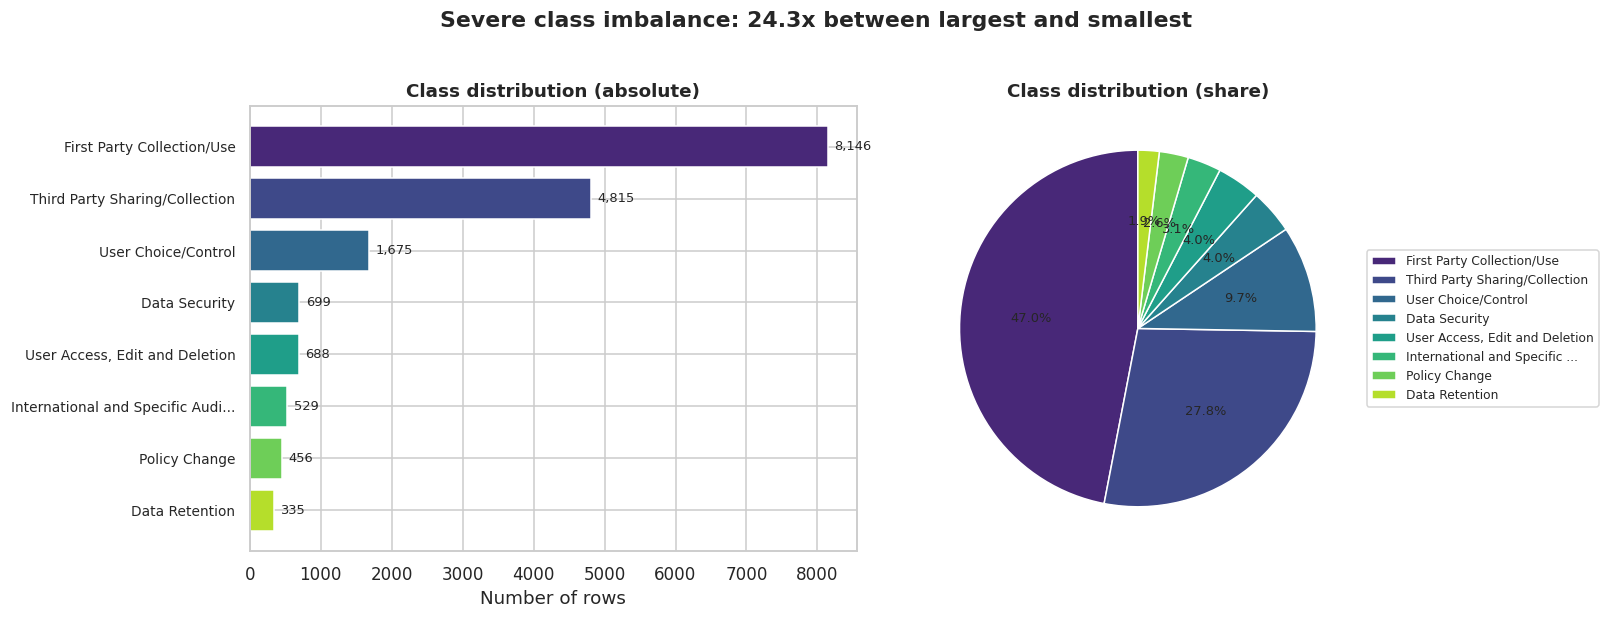

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

order = class_counts.index
colors = sns.color_palette("viridis", len(order))

axes[0].barh(range(len(order)), class_counts.values, color=colors)
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels([c if len(c) <= 34 else c[:31] + "..." for c in order], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("Number of rows")
axes[0].set_title("Class distribution (absolute)", fontweight="bold")
for i, v in enumerate(class_counts.values):
    axes[0].text(v + 90, i, f"{v:,}", va="center", fontsize=8.5)

axes[1].pie(class_counts.values, labels=None, colors=colors, autopct="%1.1f%%",
            startangle=90, textprops={"fontsize": 8.5})
axes[1].set_title("Class distribution (share)", fontweight="bold")
axes[1].legend([c if len(c) <= 30 else c[:27] + "..." for c in order],
               loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)

plt.suptitle(f"Severe class imbalance: {imbalance_ratio:.1f}x between largest and smallest",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## CLAUSE AND SPAN LENGTH STATS

In [10]:
df["span_chars"] = df["text"].fillna("").str.len()
df["span_words"] = df["text"].fillna("").str.split().str.len()
df["clause_chars"] = df["clause_text"].fillna("").str.len()
df["clause_words"] = df["clause_text"].fillna("").str.split().str.len()

length_stats = df[["span_chars", "span_words", "clause_chars", "clause_words"]].describe().round(1)
print("Length statistics:\n")
print(length_stats.to_string())

print(f"\nMean span   : {df['span_chars'].mean():.0f} chars / {df['span_words'].mean():.0f} words")
print(f"Mean clause : {df['clause_chars'].mean():.0f} chars / {df['clause_words'].mean():.0f} words")
print(f"The clause is {df['clause_chars'].mean() / df['span_chars'].mean():.1f}x longer than the span it contains.")

Length statistics:

       span_chars  span_words  clause_chars  clause_words
count     17343.0     17343.0       17343.0       17343.0
mean        136.8        21.7         636.0         100.9
std         143.9        22.9         368.3          58.2
min           3.0         1.0          24.0           5.0
25%          49.0         8.0         355.0          57.0
50%          92.0        15.0         562.0          89.0
75%         169.0        27.0         831.0         133.0
max        1873.0       289.0        2318.0         374.0

Mean span   : 137 chars / 22 words
Mean clause : 636 chars / 101 words
The clause is 4.6x longer than the span it contains.


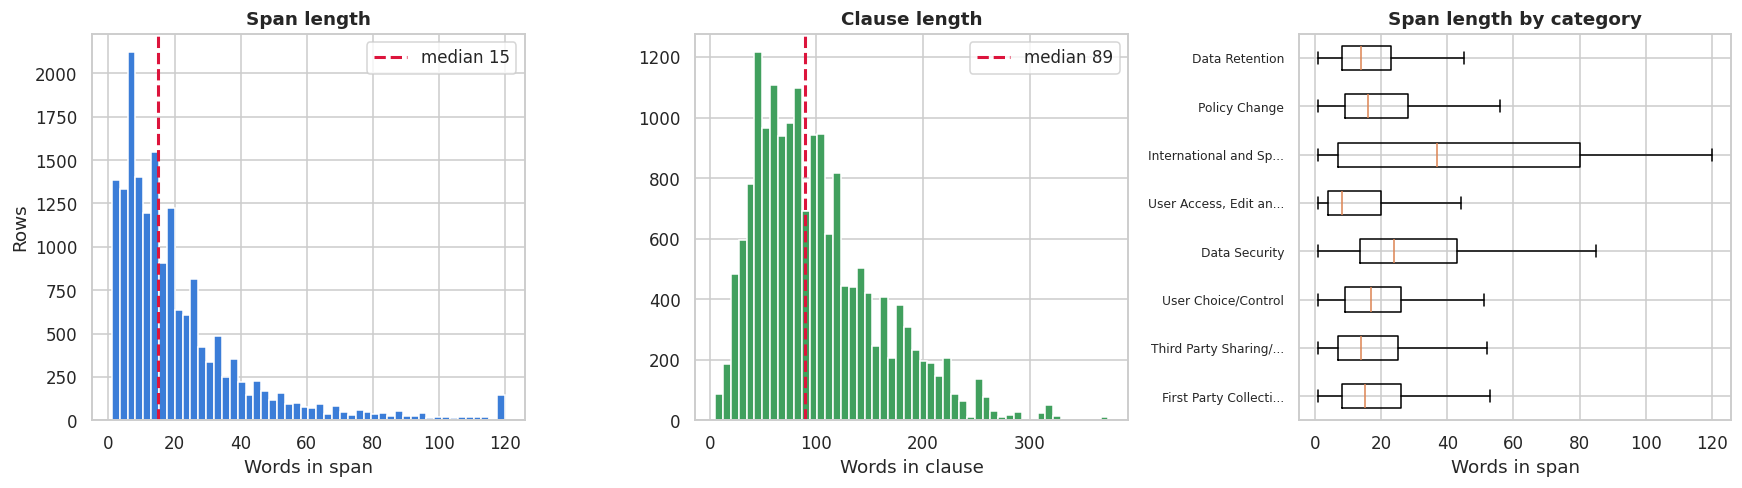

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

axes[0].hist(df["span_words"].clip(upper=120), bins=50, color="#3b7dd8", edgecolor="white")
axes[0].axvline(df["span_words"].median(), color="crimson", linestyle="--", linewidth=2,
                label=f"median {df['span_words'].median():.0f}")
axes[0].set_xlabel("Words in span")
axes[0].set_ylabel("Rows")
axes[0].set_title("Span length", fontweight="bold")
axes[0].legend()

axes[1].hist(df["clause_words"].clip(upper=400), bins=50, color="#41a05e", edgecolor="white")
axes[1].axvline(df["clause_words"].median(), color="crimson", linestyle="--", linewidth=2,
                label=f"median {df['clause_words'].median():.0f}")
axes[1].set_xlabel("Words in clause")
axes[1].set_title("Clause length", fontweight="bold")
axes[1].legend()

box_order = class_counts.index.tolist()
data = [df.loc[df["category"] == c, "span_words"].clip(upper=120).values for c in box_order]
axes[2].boxplot(data, vert=False, showfliers=False)
axes[2].set_yticks(range(1, len(box_order) + 1))
axes[2].set_yticklabels([c[:20] + "..." if len(c) > 20 else c for c in box_order])
axes[2].set_xlabel("Words in span")
axes[2].set_title("Span length by category", fontweight="bold")
axes[2].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

## MULTI CATEGORY CLAUSES

In [12]:
clause_categories = df.groupby("clause_text")["category"].nunique()
multi_clauses = (clause_categories > 1).sum()
multi_pct = multi_clauses / len(clause_categories) * 100

print(f"Distinct clauses                    : {len(clause_categories):,}")
print(f"Clauses carrying >1 category        : {multi_clauses:,} ({multi_pct:.2f}%)")
print(f"Maximum categories on one clause    : {clause_categories.max()}")

print("\nDistribution of categories per clause:")
for k, v in clause_categories.value_counts().sort_index().items():
    print(f"  {k} categor{'y ' if k == 1 else 'ies'}: {v:6,} clauses")

print("\n\nExample of a clause carrying several categories:\n")
example = clause_categories[clause_categories >= 3].index[0]
sub = df[df["clause_text"] == example]
print(f"Clause: {example[:220]}...\n")
for cat, grp in sub.groupby("category"):
    print(f"  [{cat}]")
    print(f"      span: \"{grp.iloc[0]['text'][:110]}\"")


Distinct clauses                    : 3,204
Clauses carrying >1 category        : 1,119 (34.93%)
Maximum categories on one clause    : 8

Distribution of categories per clause:
  1 category :  2,085 clauses
  2 categories:    916 clauses
  3 categories:    163 clauses
  4 categories:     34 clauses
  5 categories:      2 clauses
  6 categories:      2 clauses
  7 categories:      1 clauses
  8 categories:      1 clauses


Example of a clause carrying several categories:

Clause: (2) How we use (and do not use) personally identifiable information: This Privacy Policy serves as notice that personally identifiable information is collected during the registration process. You may choose to "opt in" ...

  [First Party Collection/Use]
      span: "This Privacy Policy serves as notice that personally identifiable information is collected during the registra"
  [Third Party Sharing/Collection]
      span: "to complete a transaction between you and such a third party."
  [User Choice/Control]


## MOST DISTINCTIVE VOCABULARY PER CLASS

In [13]:
STOP = set(stopwords.words("english"))

EXTRA_STOP = {
    "may", "us", "we", "you", "your",
    "our", "information", "the",
    "and", "or"
}


def top_terms(texts, k=12):

    counter = Counter()

    for t in texts:
        for w in re.findall(r"[a-z]{3,}", str(t).lower()):
            if w not in STOP and w not in EXTRA_STOP:
                counter[w] += 1

    return counter.most_common(k)


print("Most frequent content words by category\n" + "=" * 74)


for cat in class_counts.index:

    terms = top_terms(
        df.loc[df["category"] == cat, "text"],
        k=10
    )

    print(f"\n{cat} ({class_counts[cat]:,} rows)")
    print(
        "  " +
        ", ".join(
            f"{w}({n})"
            for w, n in terms
        )
    )

Most frequent content words by category

First Party Collection/Use (8,146 rows)
  services(2018), use(1884), site(1458), provide(1022), address(980), web(974), collect(966), cookies(882), sites(869), service(770)

Third Party Sharing/Collection (4,815 rows)
  services(1081), third(994), use(771), party(578), service(572), provide(528), personal(515), parties(512), share(394), personally(370)

User Choice/Control (1,675 rows)
  opt(405), cookies(286), email(244), receive(230), use(226), third(209), services(203), advertising(174), browser(165), privacy(163)

Data Security (699 rows)
  security(312), access(235), use(211), personal(211), protect(181), secure(170), privacy(157), data(130), unauthorized(106), measures(88)

User Access, Edit and Deletion (688 rows)
  account(197), personal(173), update(100), profile(84), access(83), request(80), delete(79), personally(77), identifiable(74), change(68)

International and Specific Audiences (529 rows)
  children(323), privacy(301), personal(

## TRAIN-TEST SPLIT INTEGRITY AND DATA LEAKAGE ANALYSIS

In [14]:
train_pool = df[df["split"] == "train"]
test_pool = df[df["split"] == "test"]

shared_clauses = set(train_pool["clause_text"]) & set(test_pool["clause_text"])
leaked_rows = test_pool["clause_text"].isin(shared_clauses).sum()

print("Dataset-level policy-disjoint split (the `split` column)")
print("=" * 100)
print(f"  Train : {len(train_pool):,} rows from {train_pool['policy_id'].nunique()} policies")
print(f"  Test  : {len(test_pool):,} rows from {test_pool['policy_id'].nunique()} policies")
print(f"  Policy overlap: {len(set(train_pool['policy_id']) & set(test_pool['policy_id']))}")

print(f"\n  Clauses appearing in both  : {len(shared_clauses)}")
print(f"  Test rows affected         : {leaked_rows:,} ({leaked_rows / len(test_pool) * 100:.1f}%)")
print("\nThis residue is real-world boilerplate reuse across unrelated policies,")
print("not a defect in the split. It is documented rather than removed.")

Dataset-level policy-disjoint split (the `split` column)
  Train : 13,432 rows from 92 policies
  Test  : 3,911 rows from 23 policies
  Policy overlap: 0

  Clauses appearing in both  : 41
  Test rows affected         : 233 (6.0%)

This residue is real-world boilerplate reuse across unrelated policies,
not a defect in the split. It is documented rather than removed.


## DATA PREPROCESSING

In [15]:
class TextCleaner:
    """Multi-variant text preprocessing for privacy policy clauses."""

    def __init__(self):

        self.stop_words = set(stopwords.words("english"))
        self.lemmatizer = WordNetLemmatizer()

        self.variants = {
            "base": self._process_base,
            "no_stopwords": self._process_no_stopwords,
            "lemmatized": self._process_lemmatized,
            "aggressive": self._process_aggressive,
            "minimal": self._process_minimal,
        }


    def _remove_html(self, text):

        text = re.sub(r"<[^>]+>", " ", text)

        return re.sub(
            r"&[a-zA-Z0-9#]+;",
            " ",
            text
        )


    def _remove_urls_emails(self, text):

        text = re.sub(
            r"http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|"
            r"(?:%[0-9a-fA-F][0-9a-fA-F]))+",
            "[URL]",
            text
        )

        return re.sub(
            r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}",
            "[EMAIL]",
            text
        )


    def _normalize_whitespace(self, text):

        return re.sub(
            r"\s+",
            " ",
            text
        ).strip()


    def _tokenize(self, text):

        return word_tokenize(text)


    def _process_base(self, text):

        text = self._remove_html(text)
        text = self._remove_urls_emails(text)

        return self._normalize_whitespace(
            text.lower()
        )


    def _process_no_stopwords(self, text):

        text = self._process_base(text)

        tokens = [
            t for t in self._tokenize(text)
            if t.lower() not in self.stop_words
        ]

        return self._normalize_whitespace(
            " ".join(tokens)
        )


    def _process_lemmatized(self, text):

        text = self._process_base(text)

        tokens = [
            self.lemmatizer.lemmatize(t)
            for t in self._tokenize(text)
        ]

        return self._normalize_whitespace(
            " ".join(tokens)
        )


    def _process_aggressive(self, text):

        text = self._process_base(text)
        tokens = [t for t in self._tokenize(text) if t.lower() not in self.stop_words]
        tokens = [self.lemmatizer.lemmatize(t) for t in tokens]

        return self._normalize_whitespace(" ".join(tokens))


    def _process_minimal(self, text):
        return self._normalize_whitespace(self._remove_html(text).lower())


    def process(self, text, variant="base"):

        if variant not in self.variants:
            raise ValueError(
                f"Unknown variant '{variant}'. Available: {list(self.variants)}")

        if not isinstance(text, str) or not text.strip():
            return ""

        return self.variants[variant](text)


    def process_batch(self, texts, variant="base"):
        return [self.process(t, variant=variant) for t in texts]


    def process_dataframe(self,df,text_column="text",variant="base",new_column=None):

        out = new_column or text_column
        df[out] = df[text_column].fillna("").apply(lambda x: self.process(x, variant=variant))

        return df


    def get_variants(self):
        return list(self.variants)



cleaner = TextCleaner()
VARIANTS = cleaner.get_variants()

print(
    "Preprocessing variants available:",
    ", ".join(VARIANTS)
)

Preprocessing variants available: base, no_stopwords, lemmatized, aggressive, minimal


DEMO(WORKING)

In [ ]:
# demo = ("<p>We collect <strong>personally identifiable information</strong> from you, "
#         "including your email address (contact: privacy@example.com) and browsing "
#         "history via https://example.com/tracking. You may review our policy at "
#         "https://example.com/privacy.</p>")

# print("ORIGINAL")
# print("-" * 96)
# print(demo)
# for v in VARIANTS:
#     print(f"\n{v.upper()}")
#     print("-" * 96)
#     print(cleaner.process(demo, variant=v))

ORIGINAL
------------------------------------------------------------------------------------------------
<p>We collect <strong>personally identifiable information</strong> from you, including your email address (contact: privacy@example.com) and browsing history via https://example.com/tracking. You may review our policy at https://example.com/privacy.</p>

BASE
------------------------------------------------------------------------------------------------
we collect personally identifiable information from you, including your email address (contact: [email]) and browsing history via [url] you may review our policy at [url]

NO_STOPWORDS
------------------------------------------------------------------------------------------------
collect personally identifiable information , including email address ( contact : [ email ] ) browsing history via [ url ] may review policy [ url ]

LEMMATIZED
----------------------------------------------------------------------------------------------

## COMPARINING VARIANTS ON THE REAL CORPUS

In [16]:
sample = df["text"].dropna().sample(n=3000, random_state=RANDOM_STATE).tolist()

rows = []
for v in VARIANTS:
    processed = cleaner.process_batch(sample, variant=v)
    vocab = {w for t in processed for w in t.split()}
    lengths = [len(t.split()) for t in processed]
    rows.append({
        "Variant": v,
        "Vocabulary": len(vocab),
        "Mean words": round(float(np.mean(lengths)), 1),
        "Median words": int(np.median(lengths)),
        "Mean chars": round(float(np.mean([len(t) for t in processed])), 1),
    })

variant_comparison = pd.DataFrame(rows)
baseline_vocab = variant_comparison.loc[variant_comparison["Variant"] == "minimal", "Vocabulary"].iloc[0]
variant_comparison["Vocab vs minimal"] = (
    (variant_comparison["Vocabulary"] / baseline_vocab - 1) * 100).round(1).astype(str) + "%"

print(f"Preprocessing variant comparison on {len(sample):,} sampled spans\n")
print(variant_comparison.to_string(index=False))

print("\n`aggressive` gives the smallest feature space and `minimal` the largest.")
print("`base` is used for the classical models below: it removes markup noise and")
print("identity without discarding the function words that mark negation.")

Preprocessing variant comparison on 3,000 sampled spans

     Variant  Vocabulary  Mean words  Median words  Mean chars Vocab vs minimal
        base        5351        22.2            15       139.2            -0.8%
no_stopwords        3387        15.3            10       104.4           -37.2%
  lemmatized        3122        25.0            17       139.3           -42.1%
  aggressive        3005        15.3            10       101.8           -44.3%
     minimal        5392        22.2            15       139.7             0.0%

`aggressive` gives the smallest feature space and `minimal` the largest.
`base` is used for the classical models below: it removes markup noise and
identity without discarding the function words that mark negation.


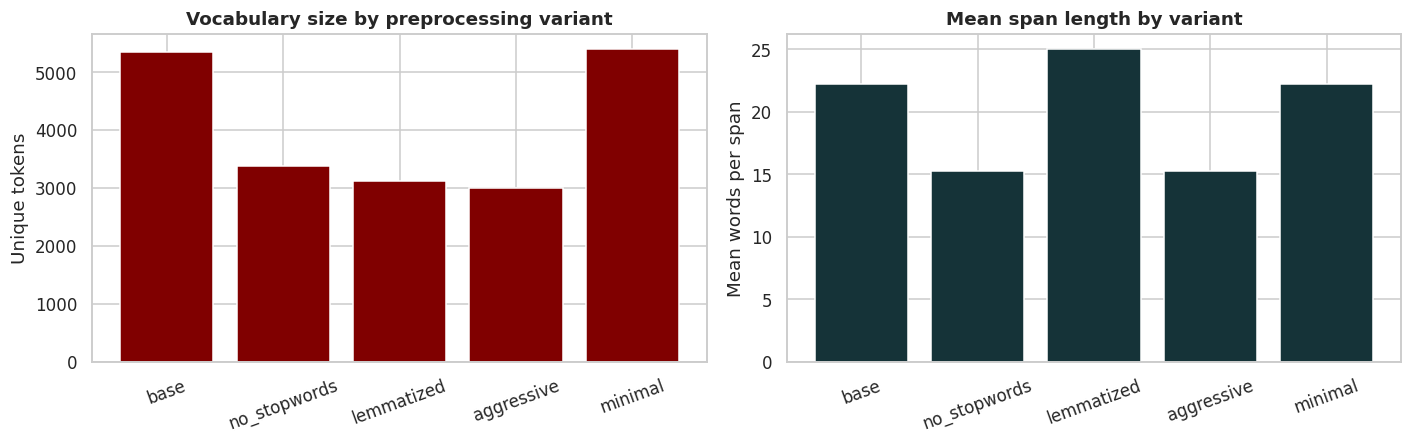

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].bar(variant_comparison["Variant"], variant_comparison["Vocabulary"], color="#800000")
axes[0].set_ylabel("Unique tokens")
axes[0].set_title("Vocabulary size by preprocessing variant", fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(variant_comparison["Variant"], variant_comparison["Mean words"], color="#153338")
axes[1].set_ylabel("Mean words per span")
axes[1].set_title("Mean span length by variant", fontweight="bold")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [18]:
PREPROCESS_VARIANT = "base"
df["text_clean"] = cleaner.process_batch(df["text"].fillna("").tolist(), variant=PREPROCESS_VARIANT)

empty_after = (df["text_clean"].str.len() == 0).sum()
print(f"Applied the `{PREPROCESS_VARIANT}` variant to all {len(df):,} spans.")
print(f"Empty after cleaning: {empty_after}")
print(f"Mean length: {df['text'].str.len().mean():.0f} chars before -> "
      f"{df['text_clean'].str.len().mean():.0f} chars after")

Applied the `base` variant to all 17,343 spans.
Empty after cleaning: 0
Mean length: 137 chars before -> 136 chars after


TRAIN, VALIDATION & TEST SPLIT

In [19]:
def build_random_scheme(df, test_size=0.15, val_size=0.15, seed=RANDOM_STATE):
    """Row-level stratified split. Policies appear on all sides."""
    train, temp = train_test_split(
        df, test_size=test_size + val_size, stratify=df["category"], random_state=seed)
    val, test = train_test_split(
        temp, test_size=test_size / (test_size + val_size),
        stratify=temp["category"], random_state=seed)
    return {"train": train.copy(), "val": val.copy(), "test": test.copy()}


def build_policy_scheme(df, val_fraction=0.1667, seed=RANDOM_STATE):
    """
    Policy-disjoint split built from the dataset's own `split` column.

    The column carries the verified 92 train / 23 test policy assignment. Validation is
    carved out of the training policies by policy, not by row, so no policy is shared
    between any pair of splits.
    """
    train_pool = df[df["split"] == "train"]
    test = df[df["split"] == "test"]

    dominant = train_pool.groupby("policy_id")["category"].agg(lambda s: s.value_counts().idxmax())
    stratify = dominant.values if (dominant.value_counts() < 2).sum() == 0 else None

    train_pol, val_pol = train_test_split(
        dominant.index.tolist(), test_size=val_fraction,
        stratify=stratify, random_state=seed)

    return {
        "train": train_pool[train_pool["policy_id"].isin(train_pol)].copy(),
        "val": train_pool[train_pool["policy_id"].isin(val_pol)].copy(),
        "test": test.copy(),
    }


def describe_scheme(name, parts):
    """Measure the leakage characteristics of a scheme before training on it."""
    tr, va, te = parts["train"], parts["val"], parts["test"]
    p_tr, p_va, p_te = (set(p["policy_id"]) for p in (tr, va, te))
    shared = set(tr["clause_text"]) & set(te["clause_text"])
    leaked = int(te["clause_text"].isin(shared).sum())

    info = {
        "scheme": name,
        "train_rows": len(tr), "val_rows": len(va), "test_rows": len(te),
        "train_policies": len(p_tr), "val_policies": len(p_va), "test_policies": len(p_te),
        "policy_overlap_train_test": len(p_tr & p_te),
        "leaked_test_rows": leaked,
        "leaked_test_pct": round(100 * leaked / max(len(te), 1), 2),
    }

    print(f"[{name}]")
    print(f"  rows      : {len(tr):,} train / {len(va):,} val / {len(te):,} test")
    print(f"  policies  : {len(p_tr)} train / {len(p_va)} val / {len(p_te)} test")
    print(f"  policy overlap train<->test : {info['policy_overlap_train_test']}")
    print(f"  test rows sharing clause text with train : {leaked:,} ({info['leaked_test_pct']}%)")
    return info


schemes = {"random": build_random_scheme(df), "policy": build_policy_scheme(df)}

scheme_info = []
for name, parts in schemes.items():
    scheme_info.append(describe_scheme(name, parts))
    print()

[random]
  rows      : 12,140 train / 2,601 val / 2,602 test
  policies  : 115 train / 114 val / 113 test
  policy overlap train<->test : 113
  test rows sharing clause text with train : 2,478 (95.23%)

[policy]
  rows      : 11,344 train / 2,088 val / 3,911 test
  policies  : 76 train / 16 val / 23 test
  policy overlap train<->test : 0
  test rows sharing clause text with train : 233 (5.96%)



scheme                       random    policy
train_rows                 12140.00  11344.00
val_rows                    2601.00   2088.00
test_rows                   2602.00   3911.00
train_policies               115.00     76.00
val_policies                 114.00     16.00
test_policies                113.00     23.00
policy_overlap_train_test    113.00      0.00
leaked_test_rows            2478.00    233.00
leaked_test_pct               95.23      5.96


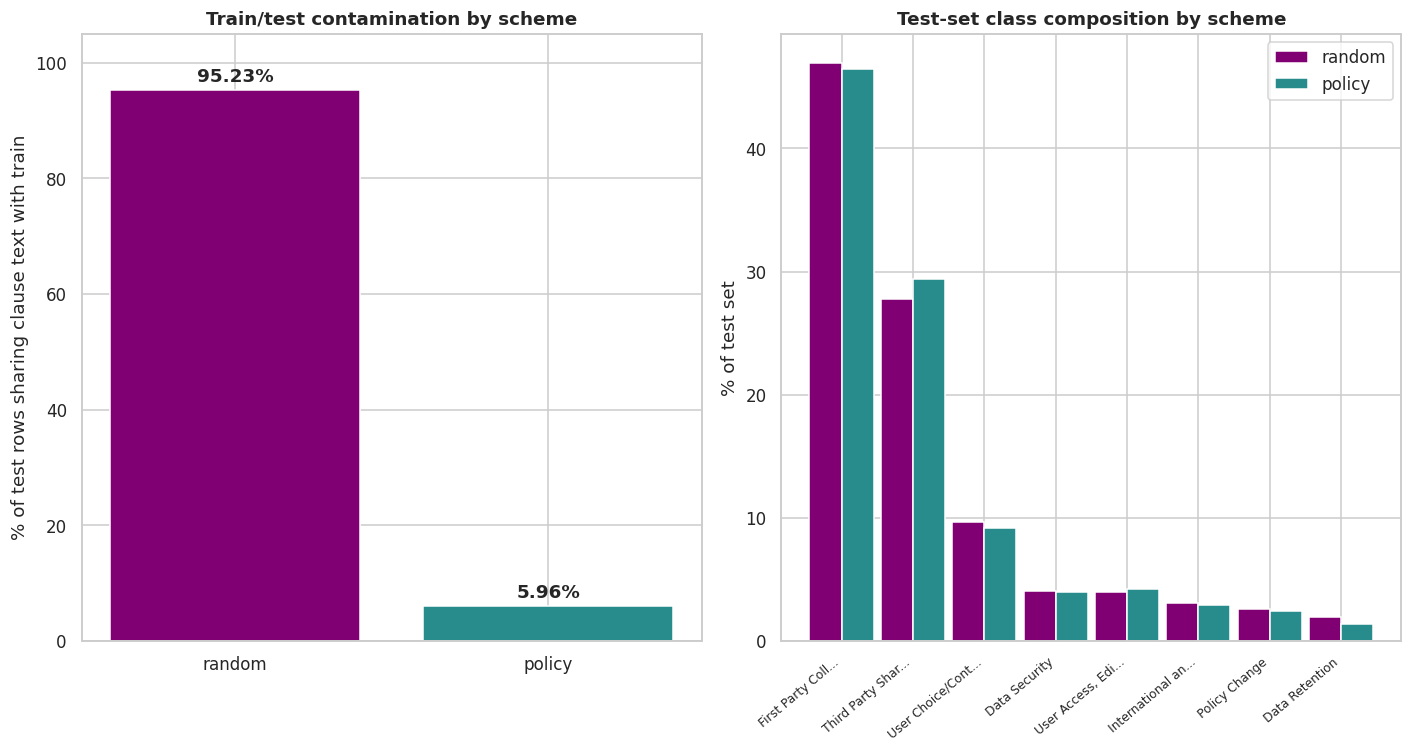

In [20]:
comparison = pd.DataFrame(scheme_info).set_index("scheme")
print(comparison.T.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 7))

names = list(schemes)
leak_pct = [comparison.loc[n, "leaked_test_pct"] for n in names]
axes[0].bar(names, leak_pct, color=["#800074", "#298C8C"])
axes[0].set_ylabel("% of test rows sharing clause text with train")
axes[0].set_title("Train/test contamination by scheme", fontweight="bold")
for i, v in enumerate(leak_pct):
    axes[0].text(i, v + 1.5, f"{v}%", ha="center", fontweight="bold")
axes[0].set_ylim(0, 105)

width = 0.45
x = np.arange(len(CATEGORIES))
short = [c[:16] + "..." if len(c) > 16 else c for c in CATEGORIES]
for offset, (name, color) in zip([-width / 2, width / 2], [("random", "#800074"), ("policy", "#298C8C")]):
    props = schemes[name]["test"]["category"].value_counts(normalize=True) * 100
    axes[1].bar(x + offset, [props.get(c, 0) for c in CATEGORIES], width, label=name, color=color)
axes[1].set_xticks(x)
axes[1].set_xticklabels(short, rotation=40, ha="right", fontsize=8)
axes[1].set_ylabel("% of test set")
axes[1].set_title("Test-set class composition by scheme", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

#TEXT REPRESENTATION

## TF-IDF

In [21]:
def build_tfidf(parts, text_column="text_clean", max_features=5000):
    """
    TF-IDF over the annotated span, fit on the training split only.

    The span is the single-label input by design: the clause carries contradictory
    signal for roughly a third of the data, as established in section 4.4.
    """
    vec = TfidfVectorizer(
        max_features=max_features, ngram_range=(1, 2), min_df=5, max_df=0.8,
        sublinear_tf=True, strip_accents="unicode", lowercase=True)
    x_train = vec.fit_transform(parts["train"][text_column].fillna(""))
    x_val = vec.transform(parts["val"][text_column].fillna(""))
    x_test = vec.transform(parts["test"][text_column].fillna(""))
    return vec, x_train, x_val, x_test


for name, parts in schemes.items():
    for key in ("train", "val", "test"):
        parts[key]["text_clean"] = cleaner.process_batch(
            parts[key]["text"].fillna("").tolist(), variant=PREPROCESS_VARIANT)

vec_demo, xtr_demo, xva_demo, xte_demo = build_tfidf(schemes["policy"])

print(f"TF-IDF matrix (policy scheme)")
print(f"  train : {xtr_demo.shape}")
print(f"  val   : {xva_demo.shape}")
print(f"  test  : {xte_demo.shape}")
print(f"  sparsity: {100 * (1 - xtr_demo.nnz / (xtr_demo.shape[0] * xtr_demo.shape[1])):.2f}%")

features = vec_demo.get_feature_names_out()
bigrams = [f for f in features if " " in f]
print(f"  features: {len(features):,}  ({len(bigrams):,} bigrams, {len(features) - len(bigrams):,} unigrams)")
print(f"\n  Sample bigrams: {', '.join(bigrams[:14])}")

TF-IDF matrix (policy scheme)
  train : (11344, 5000)
  val   : (2088, 5000)
  test  : (3911, 5000)
  sparsity: 99.43%
  features: 5,000  (3,448 bigrams, 1,552 unigrams)

  Sample bigrams: 100 secure, 101 colfax, 13 and, 13 without, 13 years, 1798 83, 90 days, 950 denver, ability to, able to, about how, about new, about our, about products



### HIGHEST MEAN TF-IDF WEIGHT PER CATEGORY



In [22]:
y_demo = schemes["policy"]["train"]["category"].values
print("Highest mean TF-IDF weight per category\n" + "=" * 78)
for cat in CATEGORIES:
    mask = y_demo == cat
    if mask.sum() == 0:
        continue
    mean_w = np.asarray(xtr_demo[mask].mean(axis=0)).ravel()
    top = np.argsort(mean_w)[::-1][:9]
    print(f"\n{cat}")
    print("  " + ", ".join(f"{features[i]}" for i in top))

Highest mean TF-IDF weight per category

First Party Collection/Use
  and, information, you, to, the, or, your, our, of

Third Party Sharing/Collection
  or, to, information, and, the, of, third, our, with

User Choice/Control
  you, to, the, your, of, or, opt, out, opt out

Data Security
  to, security, information, secure, and, the, we, access, is

User Access, Edit and Deletion
  information, account, your, personal information, personal, delete, or, update, you

International and Specific Audiences
  children, california, child, the, under, of, 13, privacy, age

Policy Change
  policy, changes, privacy, privacy policy, this, will, notice, we, the

Data Retention
  the, for, information, retain, we, and, your, our, to


## Word2Vec

In [23]:
from gensim.models import Word2Vec

def train_word2vec(sentences, vector_size=100, window=5, min_count=2, sg=1, seed=RANDOM_STATE):

    return Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=4,
        sg=sg,
        epochs=5,
        seed=seed)


def document_vectors(model, tokenized, vector_size):

    output = np.zeros((len(tokenized), vector_size), dtype=np.float32)

    for i, tokens in enumerate(tokenized):
        vectors = [model.wv[token] for token in tokens if token in model.wv]

        if vectors:
            output[i] = np.mean(vectors, axis=0)

    return output


def build_embedding_features(parts, sg=1,
                             vector_size=100,
                             text_column="text_clean"):

    tokenized = {k: [str(t).split() for t in parts[k][text_column].fillna("")] for k in ["train", "val", "test"]}

    model = train_word2vec(
        tokenized["train"],
        vector_size=vector_size,
        sg=sg
    )

    return model, (
        document_vectors(model, tokenized["train"], vector_size),
        document_vectors(model, tokenized["val"], vector_size),
        document_vectors(model, tokenized["test"], vector_size)
    )


#VOLCABULARY CONSTRUCTION AND TOKEN SEQUENCE ENCODING FOR NEURAL NETWORKS

In [25]:
MAX_LEN = 48


class Vocabulary:
    PAD, OOV = 0, 1

    def __init__(self, num_words=8000):
        self.num_words = num_words
        self.word2idx = {}

    def fit(self, texts):
        counts = {}
        for t in texts:
            for w in str(t).split():
                counts[w] = counts.get(w, 0) + 1
        ranked = sorted(counts, key=counts.get, reverse=True)[: self.num_words - 2]
        self.word2idx = {w: i + 2 for i, w in enumerate(ranked)}
        return self

    def encode(self, texts, max_len=MAX_LEN):
        out = np.zeros((len(texts), max_len), dtype=np.int64)
        for i, t in enumerate(texts):
            ids = [self.word2idx.get(w, self.OOV) for w in str(t).split()][:max_len]
            out[i, : len(ids)] = ids
        return out

    @property
    def vocab_size(self):
        return len(self.word2idx) + 2


def build_sequences(parts, text_column="text_clean", num_words=8000, max_len=MAX_LEN):
    vocab = Vocabulary(num_words=num_words).fit(parts["train"][text_column].fillna(""))
    seqs = {k: vocab.encode(parts[k][text_column].fillna(""), max_len=max_len)
           for k in ("train", "val", "test")}
    return vocab, seqs


vocab_demo, seqs_demo = build_sequences(schemes["policy"])
print(f"Vocabulary: {vocab_demo.vocab_size:,} tokens (policy scheme, training split only)")
print(f"Encoded shapes: train {seqs_demo['train'].shape}, "
      f"val {seqs_demo['val'].shape}, test {seqs_demo['test'].shape}")
print(f"\nExample span: \"{schemes['policy']['train']['text_clean'].iloc[0][:80]}\"")
print(f"        encoded: {seqs_demo['train'][0][:16]}...")


Vocabulary: 7,812 tokens (policy scheme, training split only)
Encoded shapes: train (11344, 48), val (2088, 48), test (3911, 48)

Example span: "please note that these terms are subject to change,"
        encoded: [  89  602   15   67  167   37  401    2 2549    0    0    0    0    0
    0    0]...


Bert tokenization and input encoding

In [26]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import logging as _logging

_logging.getLogger("transformers").setLevel(_logging.ERROR)
_logging.getLogger("huggingface_hub").setLevel(_logging.ERROR)

BERT_MODEL_NAME = "bert-base-uncased"
BERT_PREPROCESS_VARIANT = "minimal"
BERT_MAX_LEN = 64      # covers ~90% of WordPiece-tokenized spans (measured p90 = 59);
                       # trimmed from 96 to cut attention cost (O(len^2)) -- this
                       # project runs on an 8GB-RAM M2 laptop, not a datacenter GPU
BERT_MAX_EPOCHS = 3    # standard BERT fine-tuning budget (Devlin et al. 2019: 2-4 epochs)
BERT_PATIENCE = 1      # BERT converges fast; a wider patience mostly buys overfitting
BERT_FROZEN_LAYERS = 10  # of 12 encoder layers; freeze embeddings + layers 0-9, fine-tune
                         # only the last 2 + classifier head -- a resource-constrained
                         # partial fine-tune (Devlin et al. 2019 Sec 5.3: most task
                         # adaptation is in the top layers), cutting backward-pass compute
                         # and AdamW's per-parameter optimizer state roughly 5x

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

for name, parts in schemes.items():
    for key in ("train", "val", "test"):
        parts[key]["text_clean_bert"] = cleaner.process_batch(
            parts[key]["text"].fillna("").tolist(), variant=BERT_PREPROCESS_VARIANT)

sample_lengths = np.array([len(ids) for ids in bert_tokenizer(
    schemes["policy"]["train"]["text_clean_bert"].tolist(),
    add_special_tokens=True)["input_ids"]])
print(f"BERT tokenizer  : {BERT_MODEL_NAME}")
print(f"WordPiece length (policy train split): median {np.median(sample_lengths):.0f}, "
      f"p90 {np.percentile(sample_lengths, 90):.0f}, max {sample_lengths.max()}")
print(f"Sequence length used: {BERT_MAX_LEN} tokens")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BERT tokenizer  : bert-base-uncased
WordPiece length (policy train split): median 20, p90 59, max 369
Sequence length used: 64 tokens


In [27]:
def build_bert_encodings(parts, tokenizer, max_len=BERT_MAX_LEN):
    enc = {}

    for key in ("train", "val", "test"):

        tok = tokenizer(
            parts[key]["text_clean_bert"].fillna("").tolist(),
            padding="max_length",
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )

        enc[key] = {
            "input_ids": tok["input_ids"],
            "attention_mask": tok["attention_mask"]
        }

    return enc

**3.7  Model Development**


ML models

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB


ML_MODELS = {

    "Random Forest": lambda p: RandomForestClassifier(
        random_state=RANDOM_STATE, n_jobs=-1, **p
    ),

    "Logistic Regression": lambda p: LogisticRegression(
        random_state=RANDOM_STATE, **p
    ),

    "Naive Bayes": lambda p: MultinomialNB(**p)

}


print("Traditional ML models created:")
for model in ML_MODELS:
    print("-", model)


Traditional ML models created:
- Random Forest
- Logistic Regression
- Naive Bayes


Neural Network models


In [29]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
MAX_EPOCHS = 12
PATIENCE = 3
torch.manual_seed(RANDOM_STATE)

print(f"Device: {DEVICE}")
print(f"Max epochs: {MAX_EPOCHS}, early-stopping patience: {PATIENCE} (on validation macro-F1)")


Device: cuda
Max epochs: 12, early-stopping patience: 3 (on validation macro-F1)


In [30]:
class RNNClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        num_classes,
        embed_dim=64,
        hidden_dim=32,
        dropout=0.5,
        bidirectional=False
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=Vocabulary.PAD
        )

        self.rnn = nn.RNN(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=bidirectional
        )

        self.dropout = nn.Dropout(dropout)

        output_dim = hidden_dim * (2 if bidirectional else 1)

        self.fc = nn.Linear(
            output_dim,
            num_classes
        )


    def forward(self, x):

        embedded = self.embedding(x)

        _, hidden = self.rnn(embedded)

        if self.rnn.bidirectional:
            hidden = torch.cat(
                [hidden[-2], hidden[-1]],
                dim=1
            )

        else:
            hidden = hidden[-1]

        return self.fc(
            self.dropout(hidden)
        )

class GRUClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        num_classes,
        embed_dim=64,
        hidden_dim=32,
        dropout=0.5,
        bidirectional=False
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=Vocabulary.PAD
        )

        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=bidirectional
        )

        self.dropout = nn.Dropout(dropout)

        output_dim = hidden_dim * (2 if bidirectional else 1)

        self.fc = nn.Linear(
            output_dim,
            num_classes
        )


    def forward(self, x):

        embedded = self.embedding(x)

        _, hidden = self.gru(embedded)


        if self.gru.bidirectional:

            hidden = torch.cat(
                [hidden[-2], hidden[-1]],
                dim=1
            )

        else:

            hidden = hidden[-1]


        return self.fc(
            self.dropout(hidden)
        )

class LSTMClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        num_classes,
        embed_dim=64,
        hidden_dim=32,
        dropout=0.5,
        bidirectional=False
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=Vocabulary.PAD
        )


        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=bidirectional
        )


        self.dropout = nn.Dropout(dropout)


        output_dim = hidden_dim * (2 if bidirectional else 1)


        self.fc = nn.Linear(
            output_dim,
            num_classes
        )


    def forward(self, x):

        embedded = self.embedding(x)

        _, (hidden, _) = self.lstm(embedded)


        if self.lstm.bidirectional:

            hidden = torch.cat(
                [hidden[-2], hidden[-1]],
                dim=1
            )

        else:

            hidden = hidden[-1]


        return self.fc(
            self.dropout(hidden)
        )


NN_MODELS = {

    "SimpleRNN": lambda vocab_size, n_classes, p: RNNClassifier(
        vocab_size, n_classes, bidirectional=False,
        **{k: v for k, v in p.items() if k not in ("lr", "class_weight")}),

    "Bidirectional SimpleRNN": lambda vocab_size, n_classes, p: RNNClassifier(
        vocab_size, n_classes, bidirectional=True,
        **{k: v for k, v in p.items() if k not in ("lr", "class_weight")}),

    "GRU": lambda vocab_size, n_classes, p: GRUClassifier(
        vocab_size, n_classes, bidirectional=False,
        **{k: v for k, v in p.items() if k not in ("lr", "class_weight")}),

    "Bidirectional GRU": lambda vocab_size, n_classes, p: GRUClassifier(
        vocab_size, n_classes, bidirectional=True,
        **{k: v for k, v in p.items() if k not in ("lr", "class_weight")}),

    "LSTM": lambda vocab_size, n_classes, p: LSTMClassifier(
        vocab_size, n_classes, bidirectional=False,
        **{k: v for k, v in p.items() if k not in ("lr", "class_weight")}),

    "Bidirectional LSTM": lambda vocab_size, n_classes, p: LSTMClassifier(
        vocab_size, n_classes, bidirectional=True,
        **{k: v for k, v in p.items() if k not in ("lr", "class_weight")}),

}


print("Neural network architectures:")
for model in NN_MODELS:
    print("-", model)


Neural network architectures:
- SimpleRNN
- Bidirectional SimpleRNN
- GRU
- Bidirectional GRU
- LSTM
- Bidirectional LSTM


Bert-base model

In [31]:
from transformers import AutoModelForSequenceClassification


BERT_MODEL_NAME = "bert-base-uncased"


def build_bert_model(num_classes):

    model = AutoModelForSequenceClassification.from_pretrained(
        BERT_MODEL_NAME,
        num_labels=num_classes
    )

    return model


bert_model = build_bert_model(
    len(CATEGORIES)
)


print("BERT Base model initialized")

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERT Base model initialized


**3.8  Hyperparameter Tuning**


ML models

In [32]:
import time

LOGS_DIR = "./logs"
RESULTS_DIR = "./results"
os.makedirs(LOGS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

ML_GRIDS = {

    "Random Forest": [
        {"n_estimators": 200, "max_depth": None, "min_samples_split": 2},
        {"n_estimators": 400, "max_depth": 60, "min_samples_split": 5},
        {"n_estimators": 300, "max_depth": 30, "min_samples_split": 2,
         "class_weight": "balanced"},
    ],

    "Logistic Regression": [
        {"C": 1.0, "solver": "lbfgs", "max_iter": 1000},
        {"C": 5.0, "solver": "lbfgs", "max_iter": 2000},
        {"C": 1.0, "solver": "lbfgs", "max_iter": 2000, "class_weight": "balanced"},
    ],

    "Naive Bayes": [
        {"alpha": 1.0},
        {"alpha": 0.3},
        {"alpha": 0.05},
    ]

}


print("ML Hyperparameter Configurations")
for model_name, configs in ML_GRIDS.items():
    print(f"\n{model_name}")
    for i, config in enumerate(configs, 1):
        print(f"  Configuration {i}: {config}")


def tune_ml_models(parts):
    """Fit every (model, configuration) pair on train, score on val macro-F1, keep the winner."""

    labels = sorted(parts["train"]["category"].unique())
    vec, X_train, X_val, X_test = build_tfidf(parts)

    y_train = parts["train"]["category"].values
    y_val = parts["val"]["category"].values
    y_test = parts["test"]["category"].values

    best_models = {}
    tuning_results = []

    for model_name, configs in ML_GRIDS.items():

        best_score, best_model, best_params = -1, None, None

        for i, params in enumerate(configs, 1):

            model = ML_MODELS[model_name](params)
            start = time.time()
            model.fit(X_train, y_train)
            elapsed = time.time() - start

            y_pred = model.predict(X_val)
            score = f1_score(y_val, y_pred, average="macro")

            tuning_results.append({
                "scheme": None,  # filled in by the caller, one scheme at a time
                "Model": model_name,
                "Configuration": i,
                "Parameters": params,
                "Validation Macro F1": round(score, 4),
                "Training Seconds": round(elapsed, 1),
            })

            print(f"{model_name} | Config {i} | Macro F1 = {score:.4f}  ({elapsed:.1f}s)")

            if score > best_score:
                best_score, best_model, best_params = score, model, params

        best_models[model_name] = {
            "model": best_model,
            "parameters": best_params,
            "validation_f1": best_score,
        }

    test_data = {"X_test": X_test, "y_test": y_test, "labels": labels}
    return best_models, tuning_results, test_data


all_runs = []
all_best_ml_models = {}
all_ml_test_data = {}

print("\nStarting ML Hyperparameter Tuning for all schemes...")

for scheme_name, scheme_parts in schemes.items():
    print(f"\n--- Tuning for scheme: {scheme_name} ---")

    current_best_models, current_tuning_results, current_test_data = tune_ml_models(scheme_parts)
    for row in current_tuning_results:
        row["scheme"] = scheme_name

    all_runs.extend(current_tuning_results)
    all_best_ml_models[scheme_name] = current_best_models
    all_ml_test_data[scheme_name] = current_test_data

print(f"\nML tuning completed for {len(schemes)} schemes ({len(all_runs)} runs).")


ML Hyperparameter Configurations

Random Forest
  Configuration 1: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2}
  Configuration 2: {'n_estimators': 400, 'max_depth': 60, 'min_samples_split': 5}
  Configuration 3: {'n_estimators': 300, 'max_depth': 30, 'min_samples_split': 2, 'class_weight': 'balanced'}

Logistic Regression
  Configuration 1: {'C': 1.0, 'solver': 'lbfgs', 'max_iter': 1000}
  Configuration 2: {'C': 5.0, 'solver': 'lbfgs', 'max_iter': 2000}
  Configuration 3: {'C': 1.0, 'solver': 'lbfgs', 'max_iter': 2000, 'class_weight': 'balanced'}

Naive Bayes
  Configuration 1: {'alpha': 1.0}
  Configuration 2: {'alpha': 0.3}
  Configuration 3: {'alpha': 0.05}

Starting ML Hyperparameter Tuning for all schemes...

--- Tuning for scheme: random ---
Random Forest | Config 1 | Macro F1 = 0.7103  (57.9s)
Random Forest | Config 2 | Macro F1 = 0.6316  (24.4s)
Random Forest | Config 3 | Macro F1 = 0.6760  (19.7s)
Logistic Regression | Config 1 | Macro F1 = 0.6598  (3.4s)


In [33]:
runs_df = pd.DataFrame(all_runs)
runs_path = os.path.join(LOGS_DIR, "training_runs.csv")
runs_df.to_csv(runs_path, index=False)

display_cols = ["scheme", "Model", "Configuration", "Parameters",
                "Validation Macro F1", "Training Seconds"]
print(f"All {len(runs_df)} hyperparameter tuning runs so far\n")
print(runs_df[display_cols].to_string(index=False))
print(f"\nSaved to {runs_path}")


All 18 hyperparameter tuning runs so far

scheme               Model  Configuration                                                                                 Parameters  Validation Macro F1  Training Seconds
random       Random Forest              1                           {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2}               0.7103              57.9
random       Random Forest              2                             {'n_estimators': 400, 'max_depth': 60, 'min_samples_split': 5}               0.6316              24.4
random       Random Forest              3 {'n_estimators': 300, 'max_depth': 30, 'min_samples_split': 2, 'class_weight': 'balanced'}               0.6760              19.7
random Logistic Regression              1                                            {'C': 1.0, 'solver': 'lbfgs', 'max_iter': 1000}               0.6598               3.4
random Logistic Regression              2                                            {'C': 5.0, 's

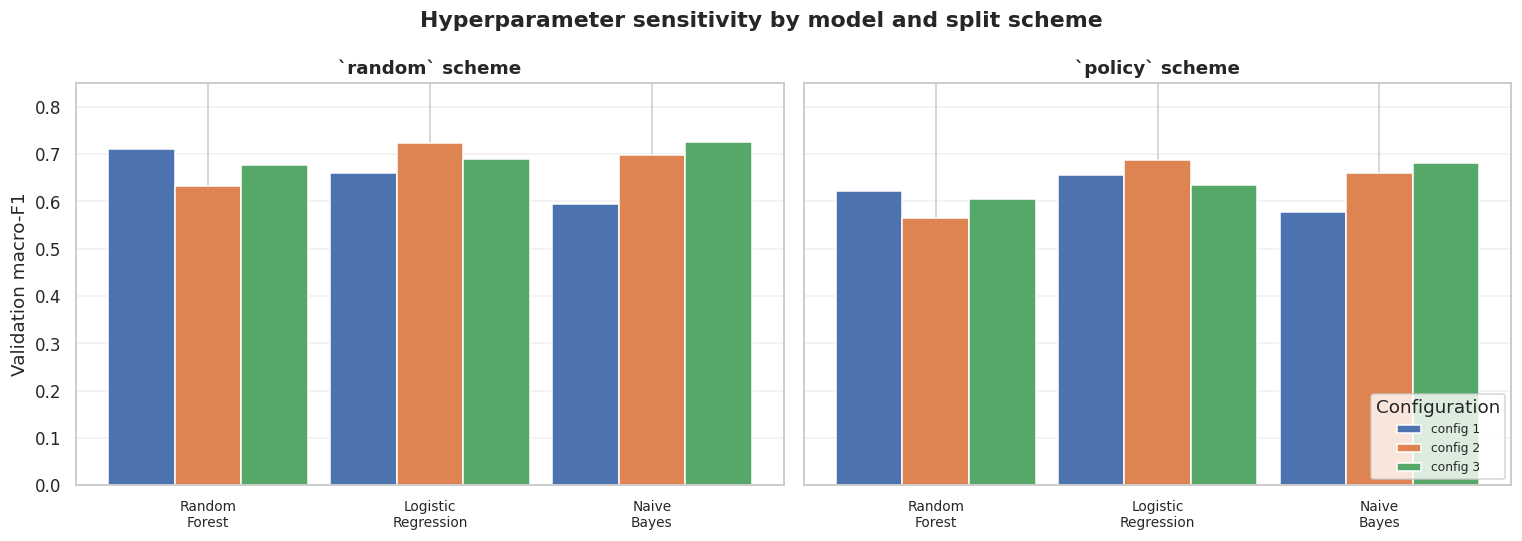

In [37]:
GRIDS = list(ML_MODELS.keys()) # Define GRIDS using the keys of ML_MODELS

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, scheme in zip(axes, schemes):
    sub = runs_df[runs_df["scheme"] == scheme]
    x = np.arange(len(GRIDS))
    width = 0.30
    for cfg in (1, 2, 3):
        vals = [sub[(sub.Model == m) & (sub.Configuration == cfg)]["Validation Macro F1"].iloc[0]
                for m in GRIDS]
        ax.bar(x + (cfg - 2) * width, vals, width, label=f"config {cfg}")
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(" ", "\n") for m in GRIDS], fontsize=9)
    ax.set_title(f"`{scheme}` scheme", fontweight="bold")
    ax.set_ylim(0, 0.85)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Validation macro-F1")
axes[1].legend(title="Configuration", loc="lower right", fontsize=8)
plt.suptitle("Hyperparameter sensitivity by model and split scheme", fontweight="bold")
plt.tight_layout()
plt.show()

Neural Network

In [38]:
GRIDS_NN = {

    "SimpleRNN": [
        {"embed_dim":64, "hidden_dim":32, "dropout":0.5, "lr":1e-3},
        {"embed_dim":128, "hidden_dim":64, "dropout":0.3, "lr":1e-3},
        {"embed_dim":64, "hidden_dim":64, "dropout":0.5, "lr":5e-4,
         "class_weight":"balanced"},
    ],

    "Bidirectional SimpleRNN": [
        {"embed_dim":64, "hidden_dim":32, "dropout":0.5, "lr":1e-3},
        {"embed_dim":128, "hidden_dim":64, "dropout":0.3, "lr":1e-3},
        {"embed_dim":64, "hidden_dim":64, "dropout":0.5, "lr":5e-4,
         "class_weight":"balanced"},
    ],

    "GRU": [
        {"embed_dim":64, "hidden_dim":32, "dropout":0.5, "lr":1e-3},
        {"embed_dim":128, "hidden_dim":64, "dropout":0.3, "lr":1e-3},
        {"embed_dim":64, "hidden_dim":64, "dropout":0.5, "lr":5e-4,
         "class_weight":"balanced"},
    ],

    "Bidirectional GRU": [
        {"embed_dim":64, "hidden_dim":32, "dropout":0.5, "lr":1e-3},
        {"embed_dim":128, "hidden_dim":64, "dropout":0.3, "lr":1e-3},
        {"embed_dim":64, "hidden_dim":64, "dropout":0.5, "lr":5e-4,
         "class_weight":"balanced"},
    ],

    "LSTM": [
        {"embed_dim":64, "hidden_dim":32, "dropout":0.5, "lr":1e-3},
        {"embed_dim":128, "hidden_dim":64, "dropout":0.3, "lr":1e-3},
        {"embed_dim":64, "hidden_dim":64, "dropout":0.5, "lr":5e-4,
         "class_weight":"balanced"},
    ],

    "Bidirectional LSTM": [
        {"embed_dim":64, "hidden_dim":32, "dropout":0.5, "lr":1e-3},
        {"embed_dim":128, "hidden_dim":64, "dropout":0.3, "lr":1e-3},
        {"embed_dim":64, "hidden_dim":64, "dropout":0.5, "lr":5e-4,
         "class_weight":"balanced"},
    ]
}

In [39]:
def make_loader(x, y, batch_size=64, shuffle=False):

    dataset = TensorDataset(
        torch.from_numpy(x),
        torch.from_numpy(y)
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle
    )

In [40]:
def train_one_config(
        model_name,
        params,
        vocab_size,
        n_classes,
        class_counts,
        train_loader,
        val_loader,
        labels
):
    """Trains one configuration with early stopping on validation macro-F1."""

    model = NN_MODELS[model_name](
        vocab_size,
        n_classes,
        params
    ).to(DEVICE)


    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params["lr"]
    )


    if params.get("class_weight") == "balanced":

        freq = np.array(
            [
                class_counts.get(labels[i], 1)
                for i in range(n_classes)
            ],
            dtype=np.float32
        )

        weights = torch.tensor(
            freq.sum() / (n_classes * freq),
            dtype=torch.float32
        ).to(DEVICE)

        criterion = nn.CrossEntropyLoss(
            weight=weights
        )

    else:

        criterion = nn.CrossEntropyLoss()


    best_f1 = -1
    best_state = None
    patience_left = PATIENCE


    for epoch in range(MAX_EPOCHS):

        model.train()

        for xb, yb in train_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            loss = criterion(
                model(xb),
                yb
            )

            loss.backward()

            optimizer.step()


        # validation score

        model.eval()

        preds = []
        actual = []


        with torch.no_grad():

            for xb, yb in val_loader:

                output = model(
                    xb.to(DEVICE)
                )

                preds.extend(
                    output.argmax(1)
                    .cpu()
                    .numpy()
                )

                actual.extend(
                    yb.numpy()
                )


        score = f1_score(
            actual,
            preds,
            average="macro"
        )


        if score > best_f1:

            best_f1 = score

            best_state = {
                k: v.clone()
                for k, v in model.state_dict().items()
            }

            patience_left = PATIENCE

        else:

            patience_left -= 1


        if patience_left <= 0:
            break


    model.load_state_dict(
        best_state
    )


    return model, best_f1


In [41]:
all_best_nn_models = {}
all_nn_test_data = {}

print("Starting NN Hyperparameter Tuning for all schemes...")

for scheme_name, scheme_parts in schemes.items():
    print(f"\n--- Tuning for scheme: {scheme_name} ---")

    labels = sorted(scheme_parts["train"]["category"].unique())
    label2id = {label: i for i, label in enumerate(labels)}
    n_classes = len(labels)
    class_counts = scheme_parts["train"]["category"].value_counts().to_dict()

    vocab, seqs = build_sequences(scheme_parts)

    y = {
        split: scheme_parts[split]["category"].map(label2id).values.astype(np.int64)
        for split in ["train", "val", "test"]
    }

    train_loader = make_loader(seqs["train"], y["train"], shuffle=True)
    val_loader = make_loader(seqs["val"], y["val"])
    test_loader = make_loader(seqs["test"], y["test"])

    print(f"    vocabulary: {vocab.vocab_size:,} tokens, device: {DEVICE}")

    best_models_this_scheme = {}

    for model_name, configs in GRIDS_NN.items():

        best_score, best_model = -1, None

        for i, params in enumerate(configs, 1):

            start = time.time()
            model, score = train_one_config(
                model_name,
                params,
                vocab.vocab_size,
                n_classes,
                class_counts,
                train_loader,
                val_loader,
                labels
            )
            elapsed = time.time() - start

            all_runs.append({
                "scheme": scheme_name,
                "Model": model_name,
                "Configuration": i,
                "Parameters": params,
                "Validation Macro F1": round(score, 4),
                "Training Seconds": round(elapsed, 1),
            })

            print(f"    {model_name} | Config {i} | Macro F1 = {score:.4f}  ({elapsed:.1f}s)")

            if score > best_score:
                best_score, best_model = score, model

        best_models_this_scheme[model_name] = best_model

    all_best_nn_models[scheme_name] = best_models_this_scheme
    all_nn_test_data[scheme_name] = {"test_loader": test_loader, "labels": labels}

print("\nNN tuning completed for all schemes.")


Starting NN Hyperparameter Tuning for all schemes...

--- Tuning for scheme: random ---
    vocabulary: 8,000 tokens, device: cuda
    SimpleRNN | Config 1 | Macro F1 = 0.1234  (7.7s)
    SimpleRNN | Config 2 | Macro F1 = 0.1674  (6.2s)
    SimpleRNN | Config 3 | Macro F1 = 0.1216  (3.6s)
    Bidirectional SimpleRNN | Config 1 | Macro F1 = 0.4365  (6.9s)
    Bidirectional SimpleRNN | Config 2 | Macro F1 = 0.5974  (7.5s)
    Bidirectional SimpleRNN | Config 3 | Macro F1 = 0.3872  (7.0s)
    GRU | Config 1 | Macro F1 = 0.3817  (7.0s)
    GRU | Config 2 | Macro F1 = 0.5233  (6.7s)
    GRU | Config 3 | Macro F1 = 0.2540  (6.7s)
    Bidirectional GRU | Config 1 | Macro F1 = 0.6511  (8.0s)
    Bidirectional GRU | Config 2 | Macro F1 = 0.6748  (7.5s)
    Bidirectional GRU | Config 3 | Macro F1 = 0.5389  (8.2s)
    LSTM | Config 1 | Macro F1 = 0.3057  (7.0s)
    LSTM | Config 2 | Macro F1 = 0.5337  (7.0s)
    LSTM | Config 3 | Macro F1 = 0.2369  (7.4s)
    Bidirectional LSTM | Config 1 | Macro

BERT

In [42]:
BERT_GRID = [

    {
        "lr": 2e-5,
        "batch_size": 16
    },

    {
        "lr": 3e-5,
        "batch_size": 32
    },

    {
        "lr": 5e-5,
        "batch_size": 16,
        "class_weight": "balanced"
    }

]


print("BERT Hyperparameter Configurations")

for i, config in enumerate(BERT_GRID, 1):
    print(f"Configuration {i}: {config}")


BERT Hyperparameter Configurations
Configuration 1: {'lr': 2e-05, 'batch_size': 16}
Configuration 2: {'lr': 3e-05, 'batch_size': 32}
Configuration 3: {'lr': 5e-05, 'batch_size': 16, 'class_weight': 'balanced'}


**3.9  Model Evaluation**




In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ML models

In [45]:
def evaluate_ml_model(model, X_test, y_test, labels):

    y_pred = model.predict(X_test)


    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    weighted_f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )


    precision, recall, f1, support = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=labels,
        zero_division=0
    )


    results = {

        "accuracy": accuracy,

        "macro_f1": macro_f1,

        "weighted_f1": weighted_f1,


        "precision": {
            label: value
            for label, value in zip(labels, precision)
        },


        "recall": {
            label: value
            for label, value in zip(labels, recall)
        },


        "f1_score": {
            label: value
            for label, value in zip(labels, f1)
        },


        "support": {
            label: value
            for label, value in zip(labels, support)
        },


        "confusion_matrix":
            confusion_matrix(
                y_test,
                y_pred,
                labels=labels
            ),


        "classification_report":
            classification_report(
                y_test,
                y_pred,
                labels=labels,
                zero_division=0
            )
    }


    return results


ml_results = {}

for scheme_name in schemes:

    ml_results[scheme_name] = {}
    test_data = all_ml_test_data[scheme_name]

    print("\n" + "=" * 78)
    print(f"SCHEME: {scheme_name}")
    print("=" * 78)

    for model_name, model_info in all_best_ml_models[scheme_name].items():

        print("\n" + "-" * 70)
        print(model_name)

        result = evaluate_ml_model(
            model_info["model"],
            test_data["X_test"],
            test_data["y_test"],
            test_data["labels"]
        )

        ml_results[scheme_name][model_name] = result

        print("Accuracy:", round(result["accuracy"], 4))
        print("Macro F1:", round(result["macro_f1"], 4))
        print("Weighted F1:", round(result["weighted_f1"], 4))
        print(result["classification_report"])



SCHEME: random

----------------------------------------------------------------------
Random Forest
Accuracy: 0.7798
Macro F1: 0.7212
Weighted F1: 0.7739
                                      precision    recall  f1-score   support

                      Data Retention       0.73      0.32      0.44        50
                       Data Security       0.98      0.61      0.75       105
          First Party Collection/Use       0.77      0.90      0.83      1222
International and Specific Audiences       0.86      0.79      0.82        80
                       Policy Change       0.95      0.78      0.85        68
      Third Party Sharing/Collection       0.77      0.73      0.75       723
      User Access, Edit and Deletion       0.80      0.53      0.64       103
                 User Choice/Control       0.78      0.60      0.68       251

                            accuracy                           0.78      2602
                           macro avg       0.83      0.66     

Confusion Matrix for ML models

Confusion matrices — policy-disjoint scheme (the honest generalization estimate)



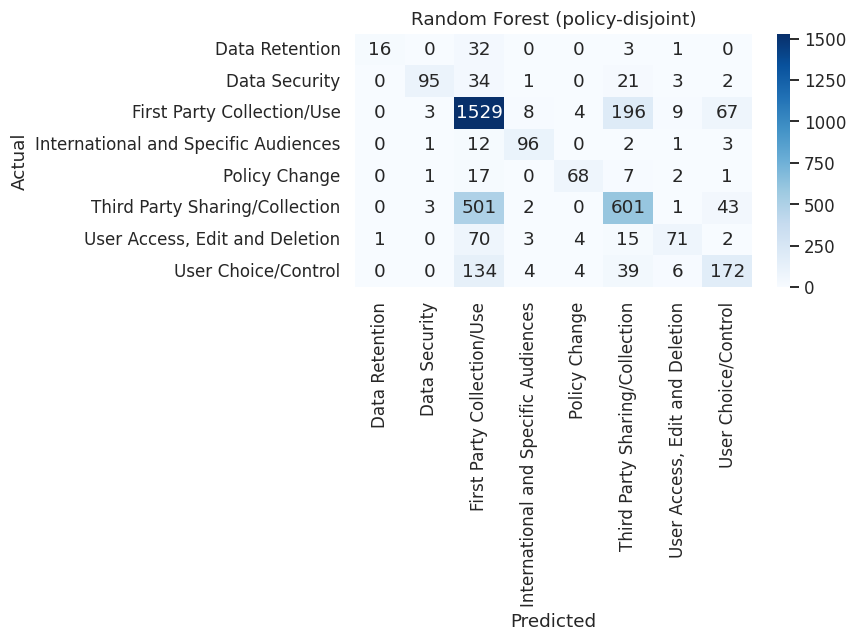

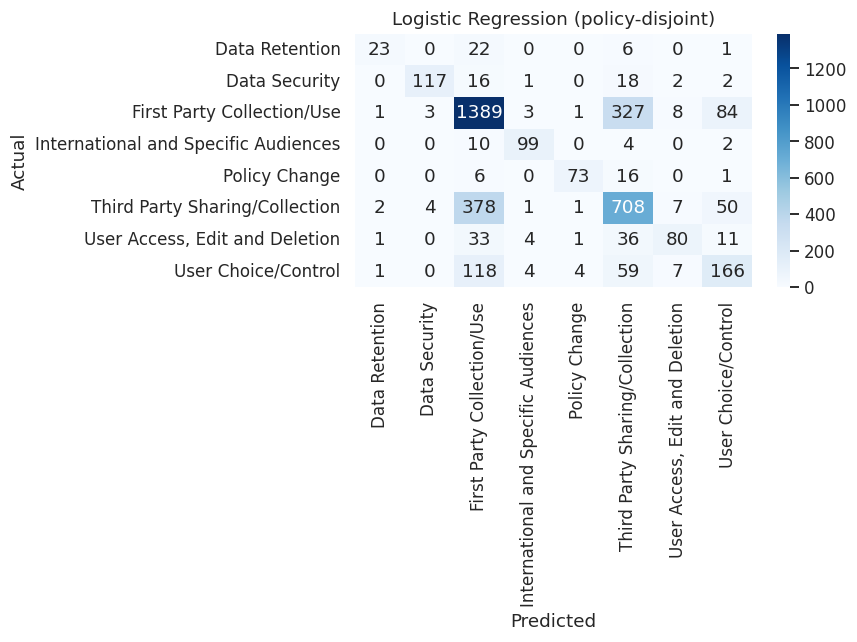

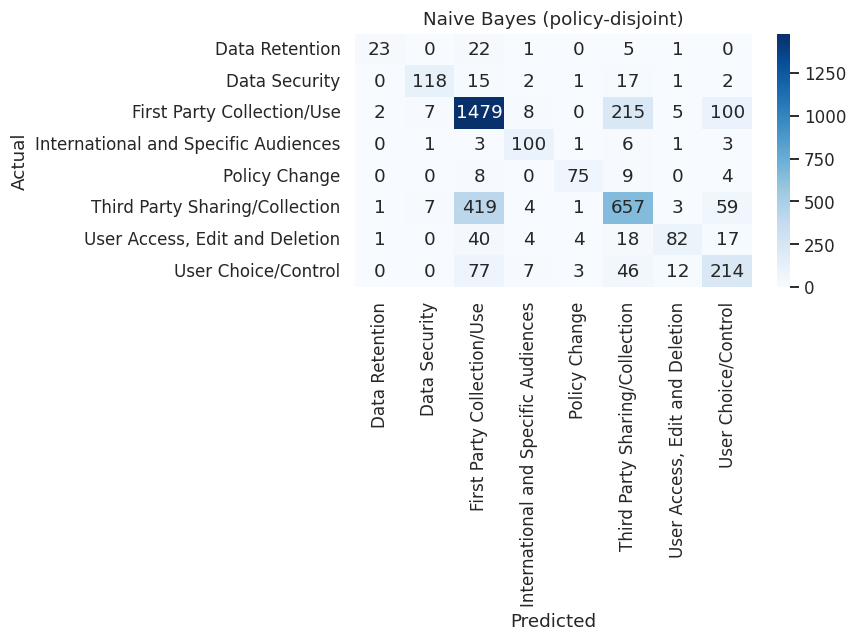

In [46]:
def plot_confusion_matrix(cm, labels, title):

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )


    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.title(title)
    plt.tight_layout()

    plt.show()


print("Confusion matrices — policy-disjoint scheme (the honest generalization estimate)\n")

for model_name, result in ml_results["policy"].items():
    plot_confusion_matrix(
        result["confusion_matrix"],
        all_ml_test_data["policy"]["labels"],
        f"{model_name} (policy-disjoint)"
    )


In [47]:
CLASSICAL_MODEL_NAMES = list(ML_MODELS.keys())


ml_payload = {

    "generated": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),

    "schemes": scheme_info,

    "models": CLASSICAL_MODEL_NAMES,

    "results": {
        scheme_name: {
            name: {k: v for k, v in result.items()}
            for name, result in models.items()
        }
        for scheme_name, models in ml_results.items()
    }

}


ml_results_path = os.path.join(
    RESULTS_DIR,
    "ml_results.json"
)


with open(
    ml_results_path,
    "w",
    encoding="utf-8"
) as fh:

    json.dump(
        ml_payload,
        fh,
        indent=2,
        default=str
    )


# Comparison table across both split schemes

ml_rows = []

for scheme_name, models in ml_results.items():
    for name, result in models.items():

        ml_rows.append({

            "Scheme": scheme_name,

            "Model": name,

            "Test Accuracy":
                round(result["accuracy"], 4),

            "Test Macro-F1":
                round(result["macro_f1"], 4),

            "Test Weighted-F1":
                round(result["weighted_f1"], 4),

            "Best Hyperparameters":
                json.dumps(
                    all_best_ml_models[scheme_name][name]["parameters"],
                    sort_keys=True
                )

        })


ml_comparison_df = pd.DataFrame(
    ml_rows
)


ml_comp_path = os.path.join(
    RESULTS_DIR,
    "ml_comparison.csv"
)


ml_comparison_df.to_csv(
    ml_comp_path,
    index=False
)


print(
    f"Classical ML evaluation artifacts saved ({len(CLASSICAL_MODEL_NAMES)} models, "
    f"{len(schemes)} schemes):"
)

print(f"  {ml_comp_path}")
print(f"  {ml_results_path}")


display(ml_comparison_df)


Classical ML evaluation artifacts saved (3 models, 2 schemes):
  ./results/ml_comparison.csv
  ./results/ml_results.json


,Scheme,Model,Test Accuracy,Test Macro-F1,Test Weighted-F1,Best Hyperparameters
0,random,Random Forest,0.7798,0.7212,0.7739,"{""max_depth"": null, ""min_samples_split"": 2, ""n..."
1,random,Logistic Regression,0.7740,0.7534,0.7713,"{""C"": 5.0, ""max_iter"": 2000, ""solver"": ""lbfgs""}"
2,random,Naive Bayes,0.7575,0.7258,0.7547,"{""alpha"": 0.05}"
3,policy,Random Forest,0.6771,0.6516,0.6673,"{""max_depth"": null, ""min_samples_split"": 2, ""n..."
4,policy,Logistic Regression,0.6789,0.6923,0.6770,"{""C"": 5.0, ""max_iter"": 2000, ""solver"": ""lbfgs""}"
5,policy,Naive Bayes,0.7026,0.7011,0.6987,"{""alpha"": 0.05}"


Neural Network

In [48]:
def evaluate_nn_model(model, loader, labels):

    model.eval()

    predictions = []
    actual = []


    with torch.no_grad():

        for xb, yb in loader:

            output = model(
                xb.to(DEVICE)
            )


            predictions.extend(
                output.argmax(1)
                .cpu()
                .numpy()
            )


            actual.extend(
                yb.numpy()
            )


    label_ids = list(range(len(labels)))


    results = {

        "accuracy":
        accuracy_score(
            actual,
            predictions
        ),


        "macro_f1":
        f1_score(
            actual,
            predictions,
            average="macro"
        ),


        "weighted_f1":
        f1_score(
            actual,
            predictions,
            average="weighted"
        ),


        "confusion_matrix":
        confusion_matrix(
            actual,
            predictions,
            labels=label_ids
        ),


        "classification_report":
        classification_report(
            actual,
            predictions,
            labels=label_ids,
            target_names=labels,
            zero_division=0
        )

    }


    return results


In [49]:
nn_results = {}

for scheme_name in schemes:

    nn_results[scheme_name] = {}
    test_data = all_nn_test_data[scheme_name]

    print("\n" + "=" * 78)
    print(f"SCHEME: {scheme_name}")
    print("=" * 78)

    for model_name, model in all_best_nn_models[scheme_name].items():

        print("\n" + "-" * 70)
        print(model_name)

        result = evaluate_nn_model(
            model,
            test_data["test_loader"],
            test_data["labels"]
        )

        nn_results[scheme_name][model_name] = result

        print("Accuracy:", round(result["accuracy"], 4))
        print("Macro F1:", round(result["macro_f1"], 4))
        print(result["classification_report"])



SCHEME: random

----------------------------------------------------------------------
SimpleRNN
Accuracy: 0.4823
Macro F1: 0.1719
                                      precision    recall  f1-score   support

                      Data Retention       0.00      0.00      0.00        50
                       Data Security       0.40      0.04      0.07       105
          First Party Collection/Use       0.52      0.85      0.65      1222
International and Specific Audiences       0.30      0.12      0.18        80
                       Policy Change       0.29      0.03      0.05        68
      Third Party Sharing/Collection       0.36      0.24      0.29       723
      User Access, Edit and Deletion       0.00      0.00      0.00       103
                 User Choice/Control       0.28      0.09      0.14       251

                            accuracy                           0.48      2602
                           macro avg       0.27      0.17      0.17      2602
        

BERT

In [50]:
def evaluate_bert_model(model, loader, labels):

    model.eval()


    predictions = []
    actual = []


    with torch.no_grad():

        for input_ids, attention_mask, y in loader:


            outputs = model(
                input_ids=input_ids.to(DEVICE),
                attention_mask=attention_mask.to(DEVICE)
            )


            pred = torch.argmax(
                outputs.logits,
                dim=1
            )


            predictions.extend(
                pred.cpu().numpy()
            )


            actual.extend(
                y.numpy()
            )


    label_ids = list(range(len(labels)))


    results = {


        "accuracy":
            accuracy_score(
                actual,
                predictions
            ),


        "macro_f1":
            f1_score(
                actual,
                predictions,
                average="macro"
            ),


        "weighted_f1":
            f1_score(
                actual,
                predictions,
                average="weighted"
            ),


        "confusion_matrix":
            confusion_matrix(
                actual,
                predictions,
                labels=label_ids
            ),


        "classification_report":
            classification_report(
                actual,
                predictions,
                labels=label_ids,
                target_names=labels,
                zero_division=0
            )

    }


    return results


def make_bert_loader(enc, y, batch_size, shuffle=False):

    dataset = TensorDataset(
        enc["input_ids"],
        enc["attention_mask"],
        torch.from_numpy(y)
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle
    )


def train_one_bert_config(params, n_classes, class_counts, labels, enc, y,
                          max_epochs=BERT_MAX_EPOCHS):
    """Trains one BERT configuration with early stopping on validation macro-F1."""

    torch.manual_seed(RANDOM_STATE)
    batch_size = params["batch_size"]
    train_loader = make_bert_loader(enc["train"], y["train"], batch_size, shuffle=True)
    val_loader = make_bert_loader(enc["val"], y["val"], batch_size)

    model = AutoModelForSequenceClassification.from_pretrained(
        BERT_MODEL_NAME, num_labels=n_classes, attn_implementation="eager"
    ).to(DEVICE)
    # attn_implementation="eager": PyTorch's fused MPS scaled_dot_product_attention
    # kernel raises NotImplementedError for dropout>0 in training mode on Apple
    # Silicon; "eager" is the pre-fused manual attention path and supports it.

    for param in model.bert.embeddings.parameters():
        param.requires_grad = False
    for layer in model.bert.encoder.layer[:BERT_FROZEN_LAYERS]:
        for param in layer.parameters():
            param.requires_grad = False
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable, lr=params["lr"])

    if params.get("class_weight") == "balanced":
        freq = np.array([class_counts.get(labels[i], 1) for i in range(n_classes)],
                        dtype=np.float32)
        weights = torch.tensor(freq.sum() / (n_classes * freq),
                               dtype=torch.float32).to(DEVICE)
        criterion = nn.CrossEntropyLoss(weight=weights)
    else:
        criterion = nn.CrossEntropyLoss()

    best_f1, best_state, patience_left = -1.0, None, BERT_PATIENCE
    for epoch in range(1, max_epochs + 1):
        model.train()
        for input_ids, attention_mask, yb in train_loader:
            input_ids, attention_mask, yb = (input_ids.to(DEVICE),
                                             attention_mask.to(DEVICE), yb.to(DEVICE))
            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, yb)
            loss.backward()
            optimizer.step()

        val = evaluate_bert_model(model, val_loader, labels)
        improved = val["macro_f1"] > best_f1
        if improved:
            best_f1 = val["macro_f1"]
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_left = BERT_PATIENCE
        else:
            patience_left -= 1

        print(f"      epoch {epoch:2d}  val macro-F1 {val['macro_f1']:.4f}  "
              f"acc {val['accuracy']:.4f}{'  *' if improved else ''}")
        if patience_left <= 0:
            break

    model.load_state_dict(best_state)
    return model, best_f1


def tune_bert_models(scheme_name, parts):

    labels = sorted(parts["train"]["category"].unique())
    label2id = {label: i for i, label in enumerate(labels)}
    n_classes = len(labels)
    class_counts = parts["train"]["category"].value_counts().to_dict()

    enc = build_bert_encodings(parts, bert_tokenizer, max_len=BERT_MAX_LEN)
    y = {
        split: parts[split]["category"].map(label2id).values.astype(np.int64)
        for split in ["train", "val", "test"]
    }

    print(f"\n[{scheme_name}] BERT Base — {BERT_MODEL_NAME}, "
          f"max_len {BERT_MAX_LEN}, device {DEVICE}")

    best_score, best_model, best_params = -1, None, None

    for i, params in enumerate(BERT_GRID, 1):
        print(f"\nConfiguration {i}: {params}")

        start_time = time.time()
        model, score = train_one_bert_config(params, n_classes, class_counts, labels, enc, y)
        elapsed_time = time.time() - start_time

        print(f"Validation Macro F1: {score:.4f}")
        print(f"Training time: {elapsed_time:.2f}s")

        all_runs.append({
            "scheme": scheme_name,
            "Model": "BERT Base",
            "Configuration": i,
            "Parameters": params,
            "Validation Macro F1": round(score, 4),
            "Training Seconds": round(elapsed_time, 1),
        })

        if score > best_score:
            best_score, best_model, best_params = score, model, params

    test_loader = make_bert_loader(enc["test"], y["test"], best_params["batch_size"])
    test_result = evaluate_bert_model(best_model, test_loader, labels)

    print(f"\nBest BERT Base config for [{scheme_name}]: {best_params}")
    print(f"  Validation Macro F1: {best_score:.4f}")
    print(f"  Test Macro F1      : {test_result['macro_f1']:.4f}")

    return best_model, best_params, best_score, test_result


bert_results = {}
best_bert_models = {}

for scheme_name, scheme_parts in schemes.items():

    model, params, val_f1, test_result = tune_bert_models(scheme_name, scheme_parts)

    best_bert_models[scheme_name] = {
        "model": model, "parameters": params, "validation_f1": val_f1
    }
    bert_results[scheme_name] = test_result

    print(f"\n{'=' * 70}")
    print(f"BERT Base — {scheme_name} scheme")
    print("Accuracy:", round(test_result["accuracy"], 4))
    print("Macro F1:", round(test_result["macro_f1"], 4))
    print(test_result["classification_report"])



[random] BERT Base — bert-base-uncased, max_len 64, device cuda

Configuration 1: {'lr': 2e-05, 'batch_size': 16}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

      epoch  1  val macro-F1 0.6081  acc 0.7055  *
      epoch  2  val macro-F1 0.6841  acc 0.7509  *
      epoch  3  val macro-F1 0.7160  acc 0.7678  *
Validation Macro F1: 0.7160
Training time: 251.68s

Configuration 2: {'lr': 3e-05, 'batch_size': 32}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

      epoch  1  val macro-F1 0.6055  acc 0.7105  *
      epoch  2  val macro-F1 0.6893  acc 0.7474  *
      epoch  3  val macro-F1 0.7137  acc 0.7666  *
Validation Macro F1: 0.7137
Training time: 246.68s

Configuration 3: {'lr': 5e-05, 'batch_size': 16, 'class_weight': 'balanced'}


...

      epoch  1  val macro-F1 0.6116  acc 0.7074  *
      epoch  2  val macro-F1 0.6707  acc 0.7102  *
      epoch  3  val macro-F1 0.7138  acc 0.7256  *
Validation Macro F1: 0.7138
Training time: 229.61s

Configuration 2: {'lr': 3e-05, 'batch_size': 32}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

      epoch  1  val macro-F1 0.6124  acc 0.6959  *
      epoch  2  val macro-F1 0.6888  acc 0.7098  *
      epoch  3  val macro-F1 0.7227  acc 0.7347  *
Validation Macro F1: 0.7227
Training time: 225.92s

Configuration 3: {'lr': 5e-05, 'batch_size': 16, 'class_weight': 'balanced'}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

      epoch  1  val macro-F1 0.6308  acc 0.6236  *
      epoch  2  val macro-F1 0.6394  acc 0.6786  *
      epoch  3  val macro-F1 0.6476  acc 0.6657  *
Validation Macro F1: 0.6476
Training time: 229.62s

Best BERT Base config for [policy]: {'lr': 3e-05, 'batch_size': 32}
  Validation Macro F1: 0.7227
  Test Macro F1      : 0.7060

BERT Base — policy scheme
Accuracy: 0.7152
Macro F1: 0.706
                                      precision    recall  f1-score   support

                      Data Retention       0.86      0.35      0.49        52
                       Data Security       0.77      0.88      0.82       156
          First Party Collection/Use       0.76      0.78      0.77      1816
International and Specific Audiences       0.86      0.88      0.87       115
                       Policy Change       0.91      0.77      0.84        96
      Third Party Sharing/Collection       0.66      0.64      0.65      1151
      User Access, Edit and Deletion       0.69      0.57   

In [51]:
# One dedicated tuning table for the whole project (spec 3.8): re-save now that the
# neural and BERT runs above have been appended to `all_runs`.
runs_df = pd.DataFrame(all_runs)
runs_df.to_csv(runs_path, index=False)
print(f"Tuning table now holds {len(runs_df)} runs (ML + NN + BERT) -> {runs_path}")


Tuning table now holds 60 runs (ML + NN + BERT) -> ./logs/training_runs.csv


Final model comparison

In [52]:
final_rows = []

for scheme_name in schemes:

    for name, result in ml_results[scheme_name].items():
        final_rows.append({
            "Scheme": scheme_name,
            "Model": name,
            "Accuracy": result["accuracy"],
            "Macro F1": result["macro_f1"],
            "Weighted F1": result["weighted_f1"],
        })

    for name, result in nn_results[scheme_name].items():
        final_rows.append({
            "Scheme": scheme_name,
            "Model": name,
            "Accuracy": result["accuracy"],
            "Macro F1": result["macro_f1"],
            "Weighted F1": result["weighted_f1"],
        })

    final_rows.append({
        "Scheme": scheme_name,
        "Model": "BERT Base",
        "Accuracy": bert_results[scheme_name]["accuracy"],
        "Macro F1": bert_results[scheme_name]["macro_f1"],
        "Weighted F1": bert_results[scheme_name]["weighted_f1"],
    })

evaluation_summary = pd.DataFrame(final_rows)

comp_path = os.path.join(RESULTS_DIR, "model_comparison.csv")
evaluation_summary.to_csv(comp_path, index=False)

print("Consolidated model comparison — classical and neural, both split schemes\n")
print(evaluation_summary.sort_values(
    ["Scheme", "Macro F1"], ascending=[True, False]
).to_string(index=False))
print(f"\nSaved to {comp_path}")


Consolidated model comparison — classical and neural, both split schemes

Scheme                   Model  Accuracy  Macro F1  Weighted F1
policy               BERT Base  0.715162  0.705969     0.713803
policy             Naive Bayes  0.702634  0.701064     0.698724
policy     Logistic Regression  0.678855  0.692328     0.676986
policy           Random Forest  0.677065  0.651642     0.667278
policy      Bidirectional LSTM  0.669905  0.608291     0.666290
policy       Bidirectional GRU  0.633086  0.585916     0.634361
policy Bidirectional SimpleRNN  0.617489  0.489070     0.609002
policy                     GRU  0.585017  0.475494     0.583244
policy                    LSTM  0.579391  0.442476     0.576356
policy               SimpleRNN  0.386346  0.130957     0.335660
random     Logistic Regression  0.774020  0.753426     0.771333
random             Naive Bayes  0.757494  0.725812     0.754742
random           Random Forest  0.779785  0.721228     0.773866
random               BERT Base

Best and worst model


In [53]:
for scheme_name in schemes:

    sub = evaluation_summary[evaluation_summary["Scheme"] == scheme_name]
    best = sub.loc[sub["Macro F1"].idxmax()]
    worst = sub.loc[sub["Macro F1"].idxmin()]

    print(f"[{scheme_name} scheme]")
    print(f"  BEST  : {best['Model']:24} macro-F1 {best['Macro F1']:.4f}  "
          f"accuracy {best['Accuracy']:.4f}")
    print(f"  WORST : {worst['Model']:24} macro-F1 {worst['Macro F1']:.4f}  "
          f"accuracy {worst['Accuracy']:.4f}")
    print()

# The policy-disjoint scheme is the honest generalization estimate (locked decision 5) —
# it is the one reported as the project's headline result.
honest = evaluation_summary[evaluation_summary["Scheme"] == "policy"]
overall_best = honest.loc[honest["Macro F1"].idxmax()]
overall_worst = honest.loc[honest["Macro F1"].idxmin()]

print("=" * 66)
print("REPORTED RESULT — policy-disjoint evaluation is the honest estimate")
print("=" * 66)
print(f"  Best-performing model  : {overall_best['Model']}  "
      f"(test macro-F1 {overall_best['Macro F1']:.4f})")
print(f"  Worst-performing model : {overall_worst['Model']}  "
      f"(test macro-F1 {overall_worst['Macro F1']:.4f})")


[random scheme]
  BEST  : Logistic Regression      macro-F1 0.7534  accuracy 0.7740
  WORST : SimpleRNN                macro-F1 0.1719  accuracy 0.4823

[policy scheme]
  BEST  : BERT Base                macro-F1 0.7060  accuracy 0.7152
  WORST : SimpleRNN                macro-F1 0.1310  accuracy 0.3863

REPORTED RESULT — policy-disjoint evaluation is the honest estimate
  Best-performing model  : BERT Base  (test macro-F1 0.7060)
  Worst-performing model : SimpleRNN  (test macro-F1 0.1310)


Effect of train/test leakage — random vs. policy-disjoint


Leakage effect: how much the conventional (random) split overstates each model

                  Model  Macro F1 (random)  Macro F1 (policy)  Macro F1 inflation  Accuracy inflation
Bidirectional SimpleRNN           0.611844           0.489070              0.1228              0.1108
      Bidirectional GRU           0.699958           0.585916              0.1140              0.1309
                   LSTM           0.548919           0.442476              0.1064              0.1120
     Bidirectional LSTM           0.683967           0.608291              0.0757              0.0899
          Random Forest           0.721228           0.651642              0.0696              0.1027
    Logistic Regression           0.753426           0.692328              0.0611              0.0952
                    GRU           0.519371           0.475494              0.0439              0.1260
              SimpleRNN           0.171928           0.130957              0.0410              0.0960
  

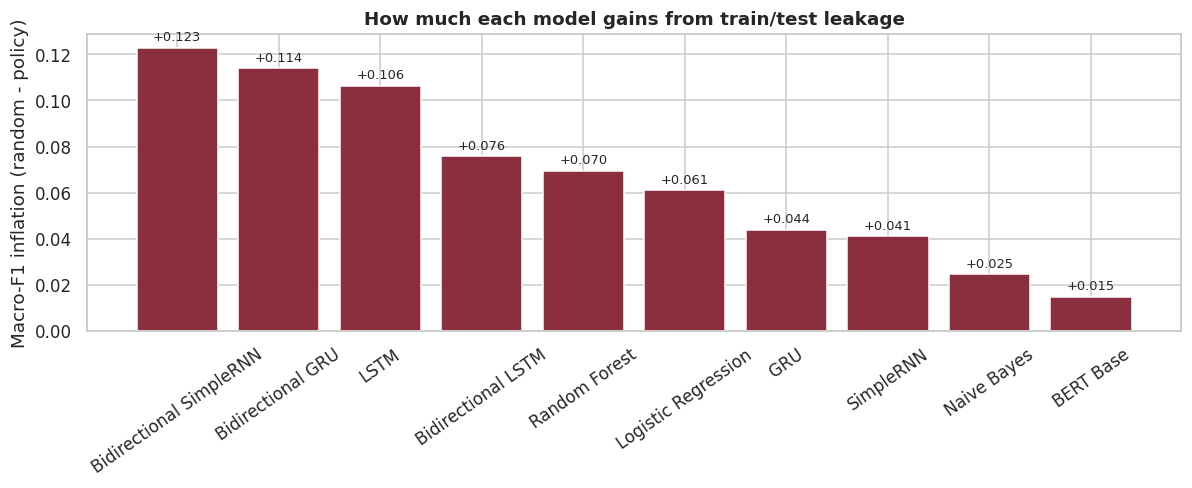

In [54]:
leak_rows = []

for model_name in evaluation_summary["Model"].unique():

    r = evaluation_summary[(evaluation_summary.Scheme == "random") &
                           (evaluation_summary.Model == model_name)]
    p = evaluation_summary[(evaluation_summary.Scheme == "policy") &
                           (evaluation_summary.Model == model_name)]

    if len(r) and len(p):
        leak_rows.append({
            "Model": model_name,
            "Macro F1 (random)": r["Macro F1"].iloc[0],
            "Macro F1 (policy)": p["Macro F1"].iloc[0],
            "Macro F1 inflation": round(r["Macro F1"].iloc[0] - p["Macro F1"].iloc[0], 4),
            "Accuracy inflation": round(r["Accuracy"].iloc[0] - p["Accuracy"].iloc[0], 4),
        })

leakage_df = pd.DataFrame(leak_rows).sort_values("Macro F1 inflation", ascending=False)

print("Leakage effect: how much the conventional (random) split overstates each model\n")
print(leakage_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.bar(leakage_df["Model"], leakage_df["Macro F1 inflation"], color="#8b2f3f")
ax.set_ylabel("Macro-F1 inflation (random - policy)")
ax.set_title("How much each model gains from train/test leakage", fontweight="bold")
ax.tick_params(axis="x", rotation=35)
for i, v in enumerate(leakage_df["Macro F1 inflation"]):
    ax.text(i, v + 0.003, f"+{v:.3f}", ha="center", fontsize=8.5)
plt.tight_layout()
plt.show()


In [55]:
model_payload = {

    "generated": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),

    "schemes": list(schemes),

    "results": {
        "ml": ml_results,
        "nn": nn_results,
        "bert": bert_results,
    },

}


def _json_default(o):
    if hasattr(o, "tolist"):
        return o.tolist()
    return str(o)


model_results_path = os.path.join(RESULTS_DIR, "model_results.json")

with open(model_results_path, "w", encoding="utf-8") as fh:
    json.dump(model_payload, fh, indent=2, default=_json_default)

print(f"Consolidated results (classical + neural + BERT, both schemes) saved to "
      f"{model_results_path}")
print(f"Consolidated comparison table saved to {comp_path}")


Consolidated results (classical + neural + BERT, both schemes) saved to ./results/model_results.json
Consolidated comparison table saved to ./results/model_comparison.csv
